In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", message=r"invalid value encountered in log10", category=RuntimeWarning, module=r".*specparam.*")

from specparam import Bands
from spk_feat_cluster_analysis import *
from spe1_plotting import *
from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT, LFP_FS


In [3]:
cell_num = 3

lfp_fs   = LFP_FS                    # from config
patch_fs = DICT_PATCH_FS[cell_num]

FORCE_LFP    = False  # True → reextract LFP windows even if pickle exists
FORCE_SIMPLE = False  # True → recompute simple LFP features even if pickle exists
FORCE_STATS  = False  # True → rerun sliding-window stats even if pickle exists


In [4]:
# Parameters
FORCE_LFP = False
FORCE_SIMPLE = False
FORCE_STATS = False


In [5]:
# Load pre-processed .npy recordings
lfp_dir   = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings',  f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')

lfp_filt   = np.load(lfp_dir)
patch_filt = np.load(patch_dir)

lfp_times   = np.arange(len(lfp_filt))   / (lfp_fs   / 1000.0)  # ms
patch_times = np.arange(len(patch_filt)) / (patch_fs  / 1000.0)  # ms


In [6]:
# Load cluster DataFrame from pickle (run spe-1_c{cell_num}_clusters.ipynb first)
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')
with open(cluster_pickle, 'rb') as f:
    df_features_clust = pickle.load(f)
print(f"Loaded {len(df_features_clust)} spikes with columns: {[c for c in df_features_clust.columns if '_cluster' in c]}")


Loaded 675 spikes with columns: ['peak_amp_cluster', 'log_isi_cluster', 'spk_times_idx_cluster', 'spk_times_ms_cluster']


In [7]:
# Load or extract LFP windows around each spike
lfp_win_pickle = os.path.join(SPE1_PICKLE_ROOT, 'lfp_window_pickles', f'c{cell_num}_lfp_windows.pkl')

if FORCE_LFP or not os.path.exists(lfp_win_pickle):
    all_spike_extractor = extract_lfp_windows(
        spk_df=df_features_clust,
        lfp_times_ms=lfp_times,
        lfp_signal=lfp_filt,
        pre_s=1.0, post_s=1.5,
        condition=None,
    )
    with open(lfp_win_pickle, 'wb') as f:
        pickle.dump(all_spike_extractor, f)
    print(f"  Saved: {os.path.basename(lfp_win_pickle)}")
else:
    print(f"  [cache] {os.path.basename(lfp_win_pickle)}")
    with open(lfp_win_pickle, 'rb') as f:
        all_spike_extractor = pickle.load(f)

windows_all     = all_spike_extractor["windows"]
t_rel_all       = all_spike_extractor["times_rel_ms"]
next_spk_all    = all_spike_extractor["next_spike_times_ms"]


  Saved: c3_lfp_windows.pkl


In [8]:
# Load pre-computed specparam chunks
chunk_dir = os.path.join(SPE1_PICKLE_ROOT, 'multitaper_pickles', f'c{cell_num}')
specparam_by_spike = load_chunked_specparam_results(save_dir=chunk_dir, prefix=f"c{cell_num}_specparam")
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)
print(f"Loaded specparam for {len(specparam_by_spike)} spikes")


No files found in /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c3 starting with 'c3_specparam'.
Loaded specparam for 0 spikes


In [9]:
groups = build_lfp_groups_from_clusters(df_features_clust, all_spike_extractor)
print(f"Groups: {list(groups.keys())}")


Groups: ['peak_amp_cluster: high', 'peak_amp_cluster: low', 'log_isi_cluster: low', 'log_isi_cluster: high', 'spk_times_idx_cluster: low', 'spk_times_idx_cluster: high', 'spk_times_ms_cluster: low', 'spk_times_ms_cluster: high']


In [10]:
# Compute (or load) simple LFP features per spike window
simple_pickle = os.path.join(SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl')

if FORCE_SIMPLE or not os.path.exists(simple_pickle):
    lfp_windows_by_spike = compute_simple_lfp_by_spike(
        windows_all=windows_all,
        times_rel_list=t_rel_all,
        fs=lfp_fs,
        inner_window_s=0.5,
        step_s=0.025,
        freq_range=(4, 90),
    )
    with open(simple_pickle, 'wb') as f:
        pickle.dump(lfp_windows_by_spike, f)
    print(f"  Saved: {os.path.basename(simple_pickle)}")
else:
    print(f"  [cache] {os.path.basename(simple_pickle)}")
    with open(simple_pickle, 'rb') as f:
        lfp_windows_by_spike = pickle.load(f)


  Saved: c3_simple_lfp.pkl


## Run sliding-window LFP-spike group analysis


  RUNNING PIPELINE FOR: APERIODIC EXPONENT


  RUNNING PIPELINE FOR: APERIODIC OFFSET


  RUNNING PIPELINE FOR: THETA AUC


  RUNNING PIPELINE FOR: BETA AUC


  RUNNING PIPELINE FOR: GAMMA AUC


  RUNNING PIPELINE FOR: R-SQUARED


  RUNNING PIPELINE FOR: LFP MEAN AMPLITUDE



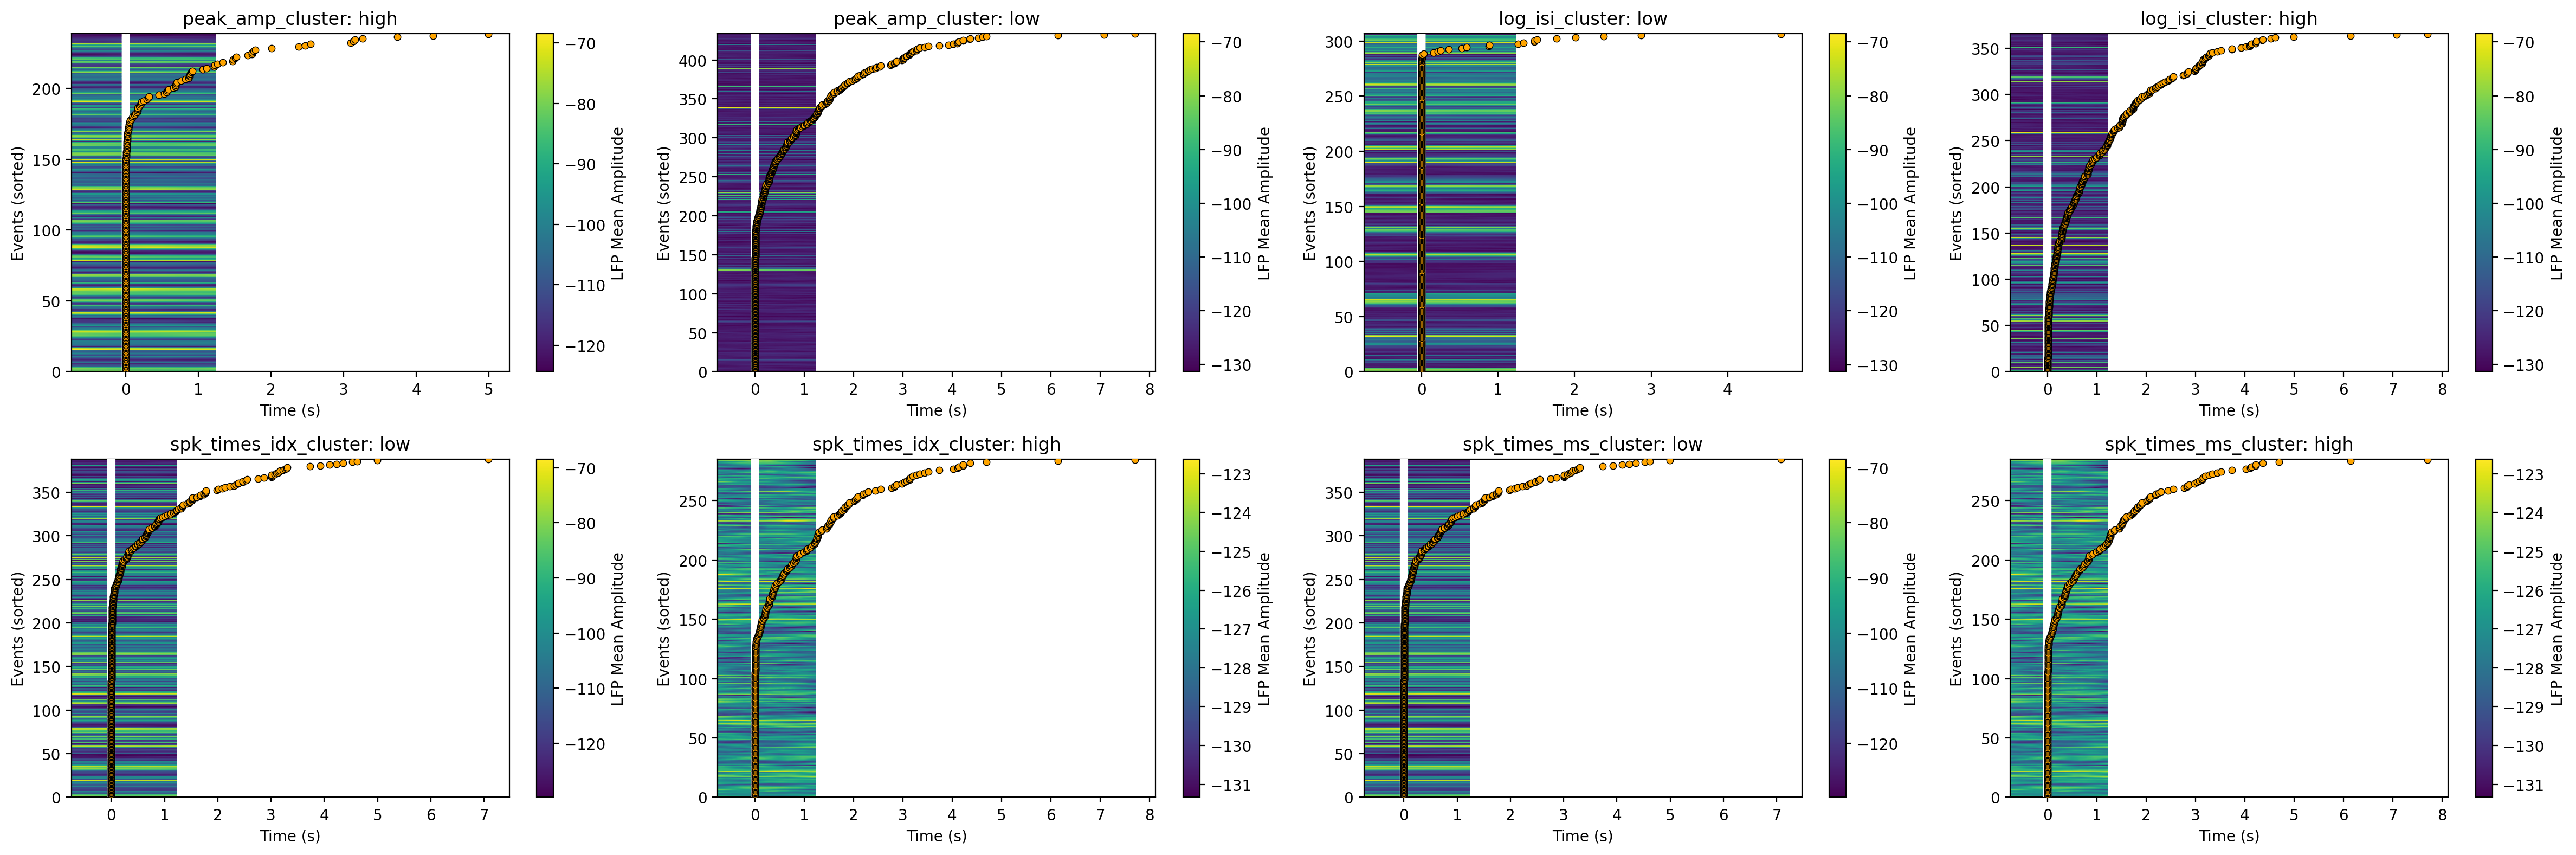

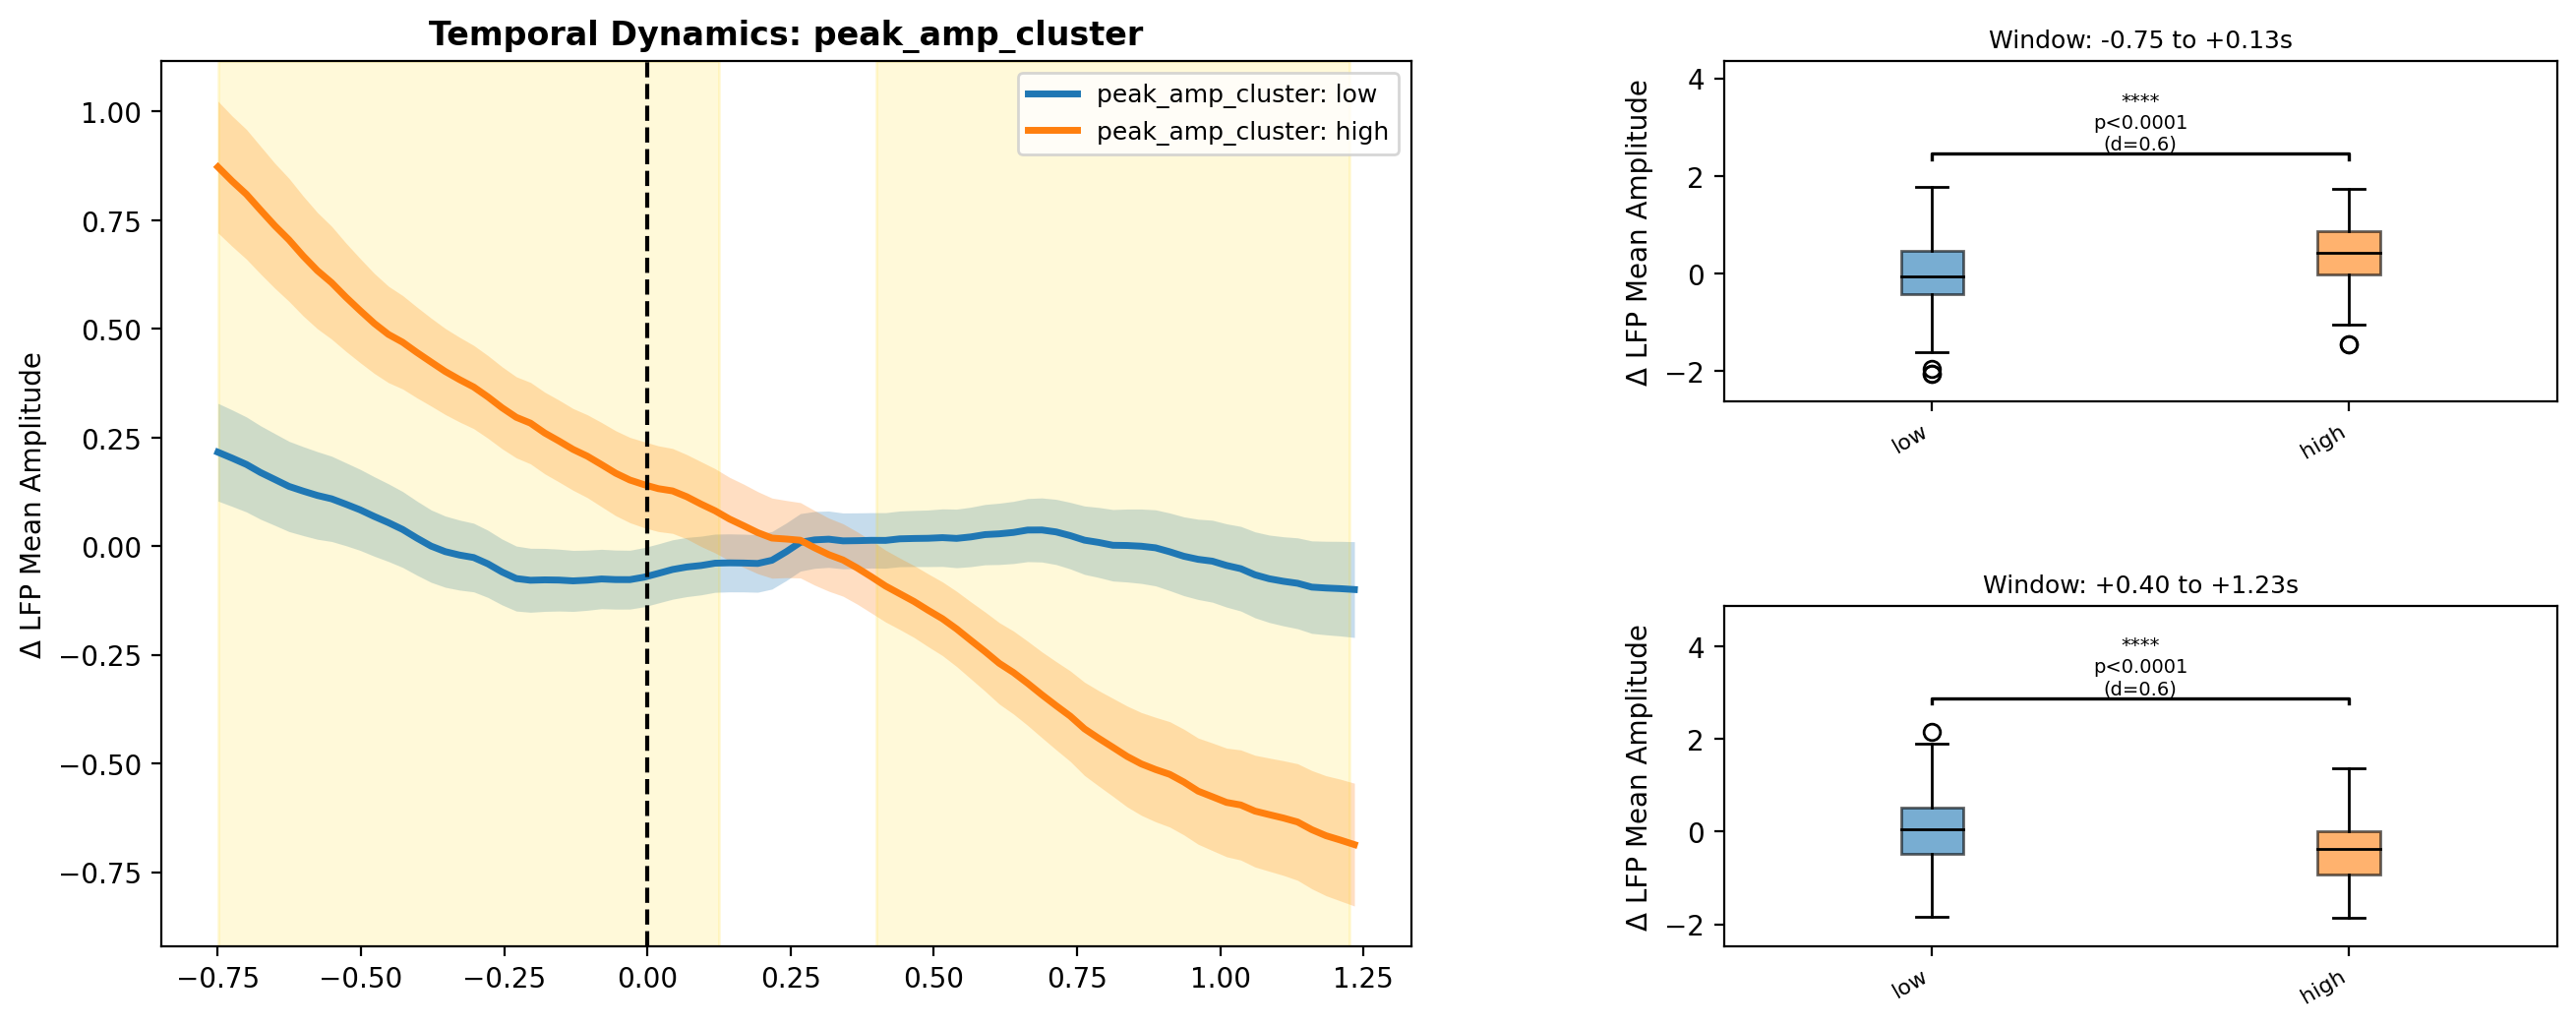

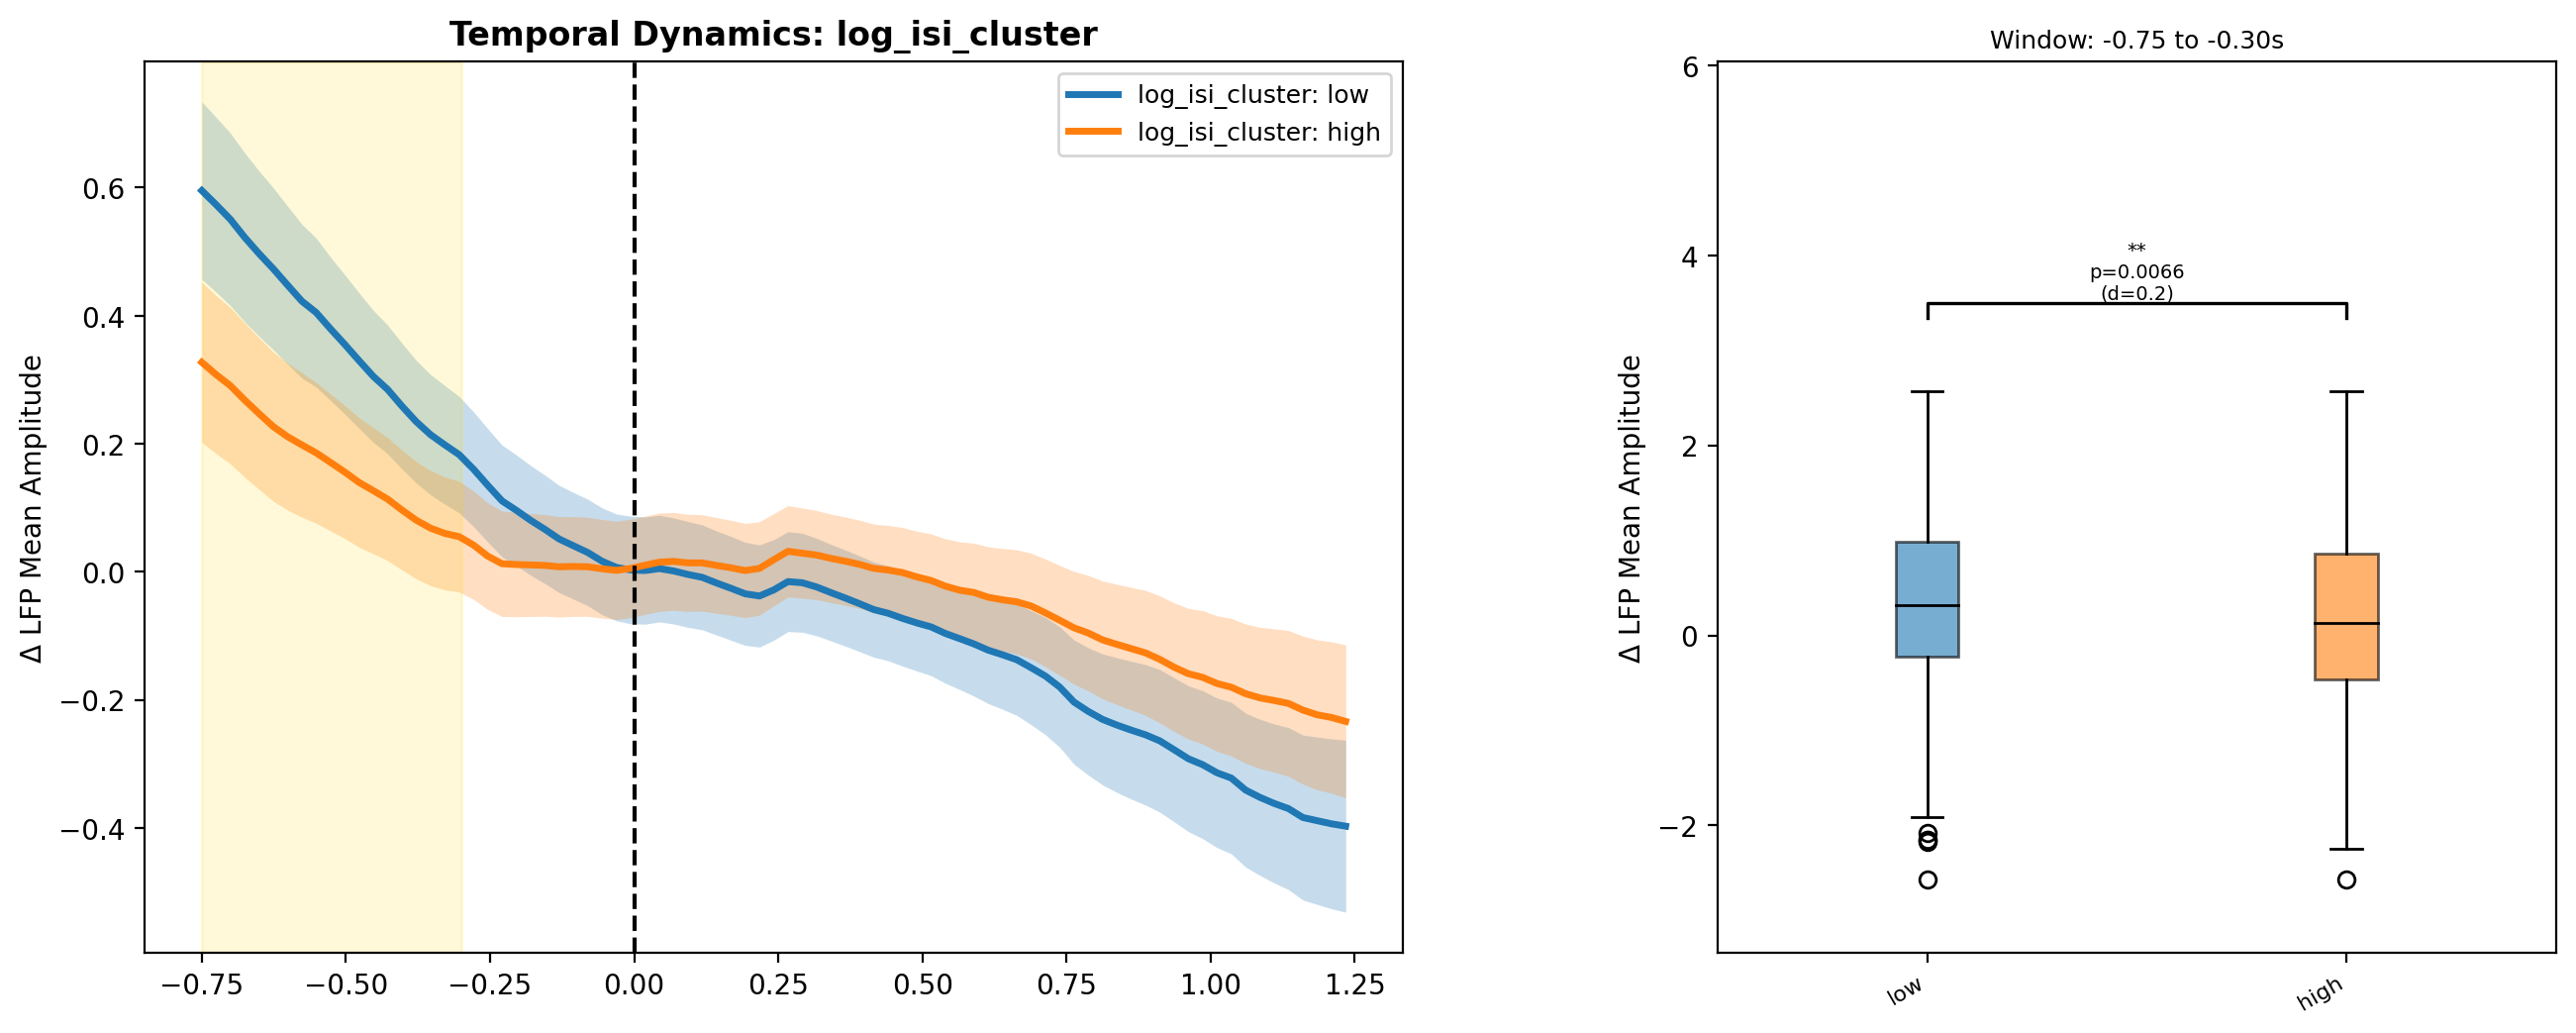

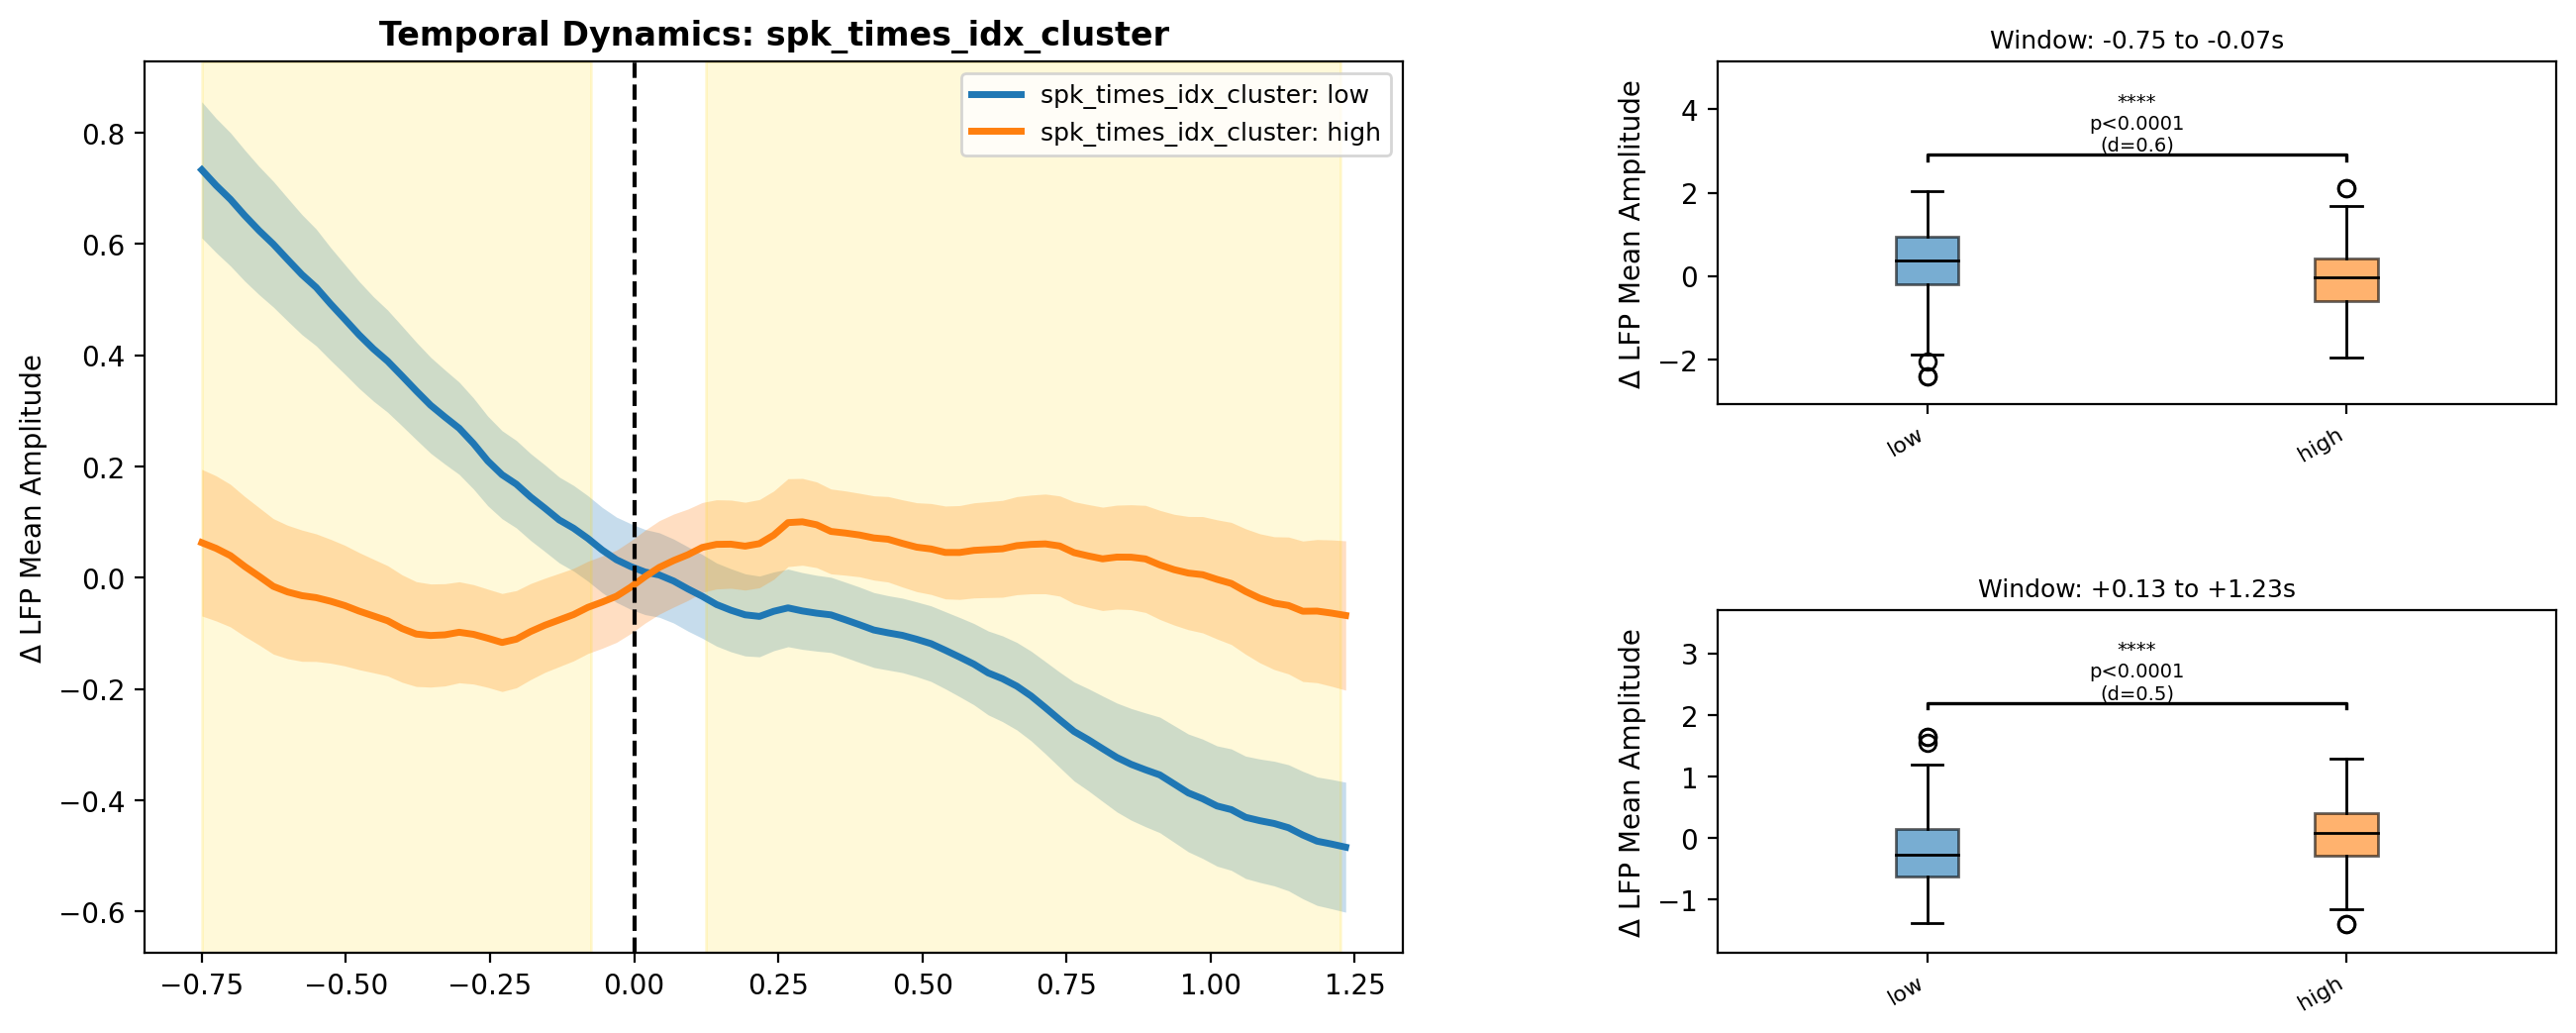

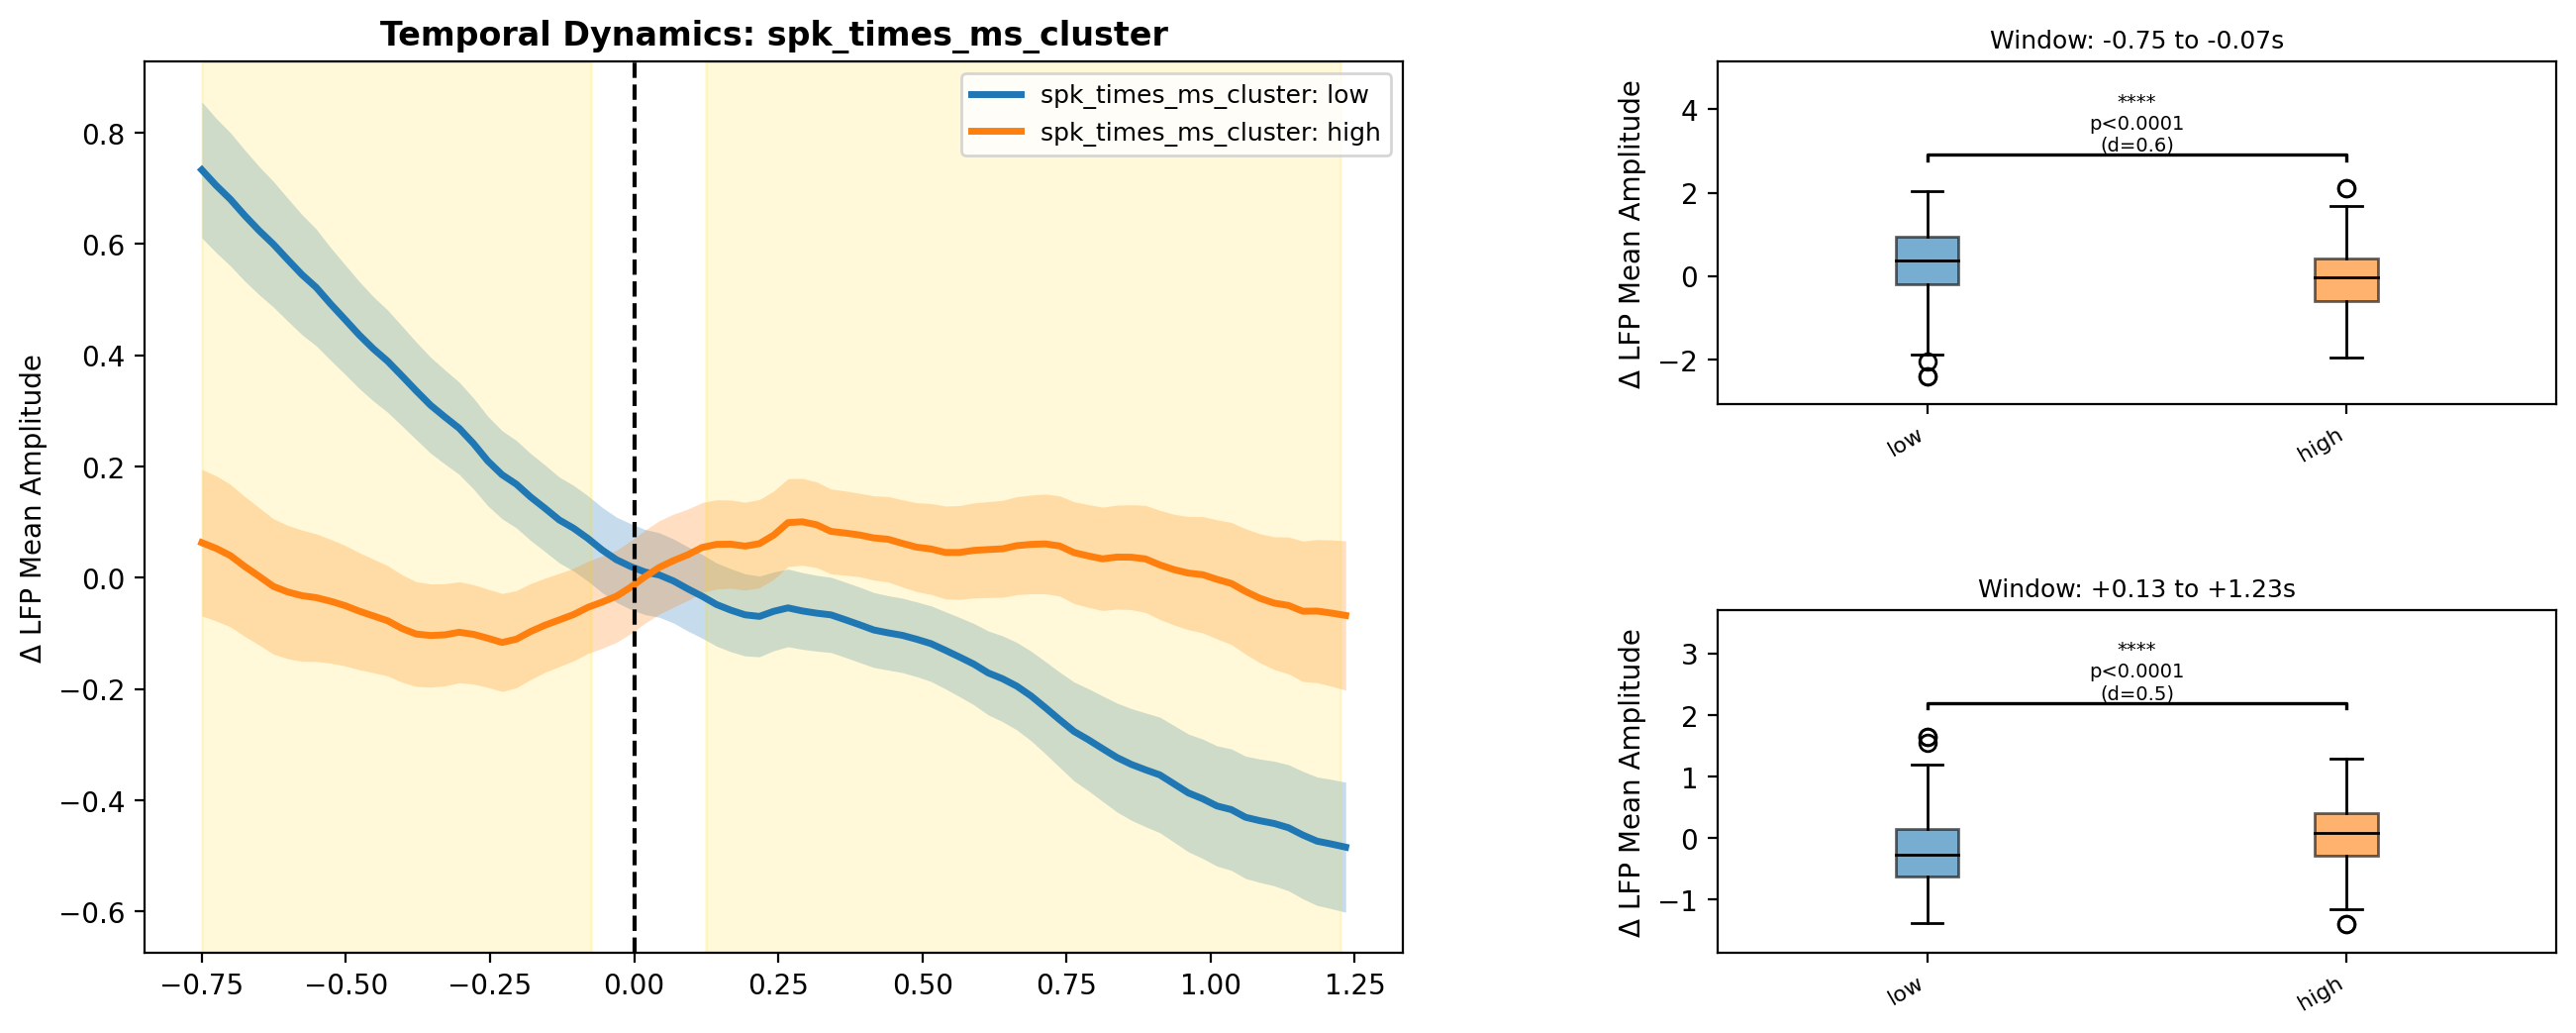


  RUNNING PIPELINE FOR: LFP STD



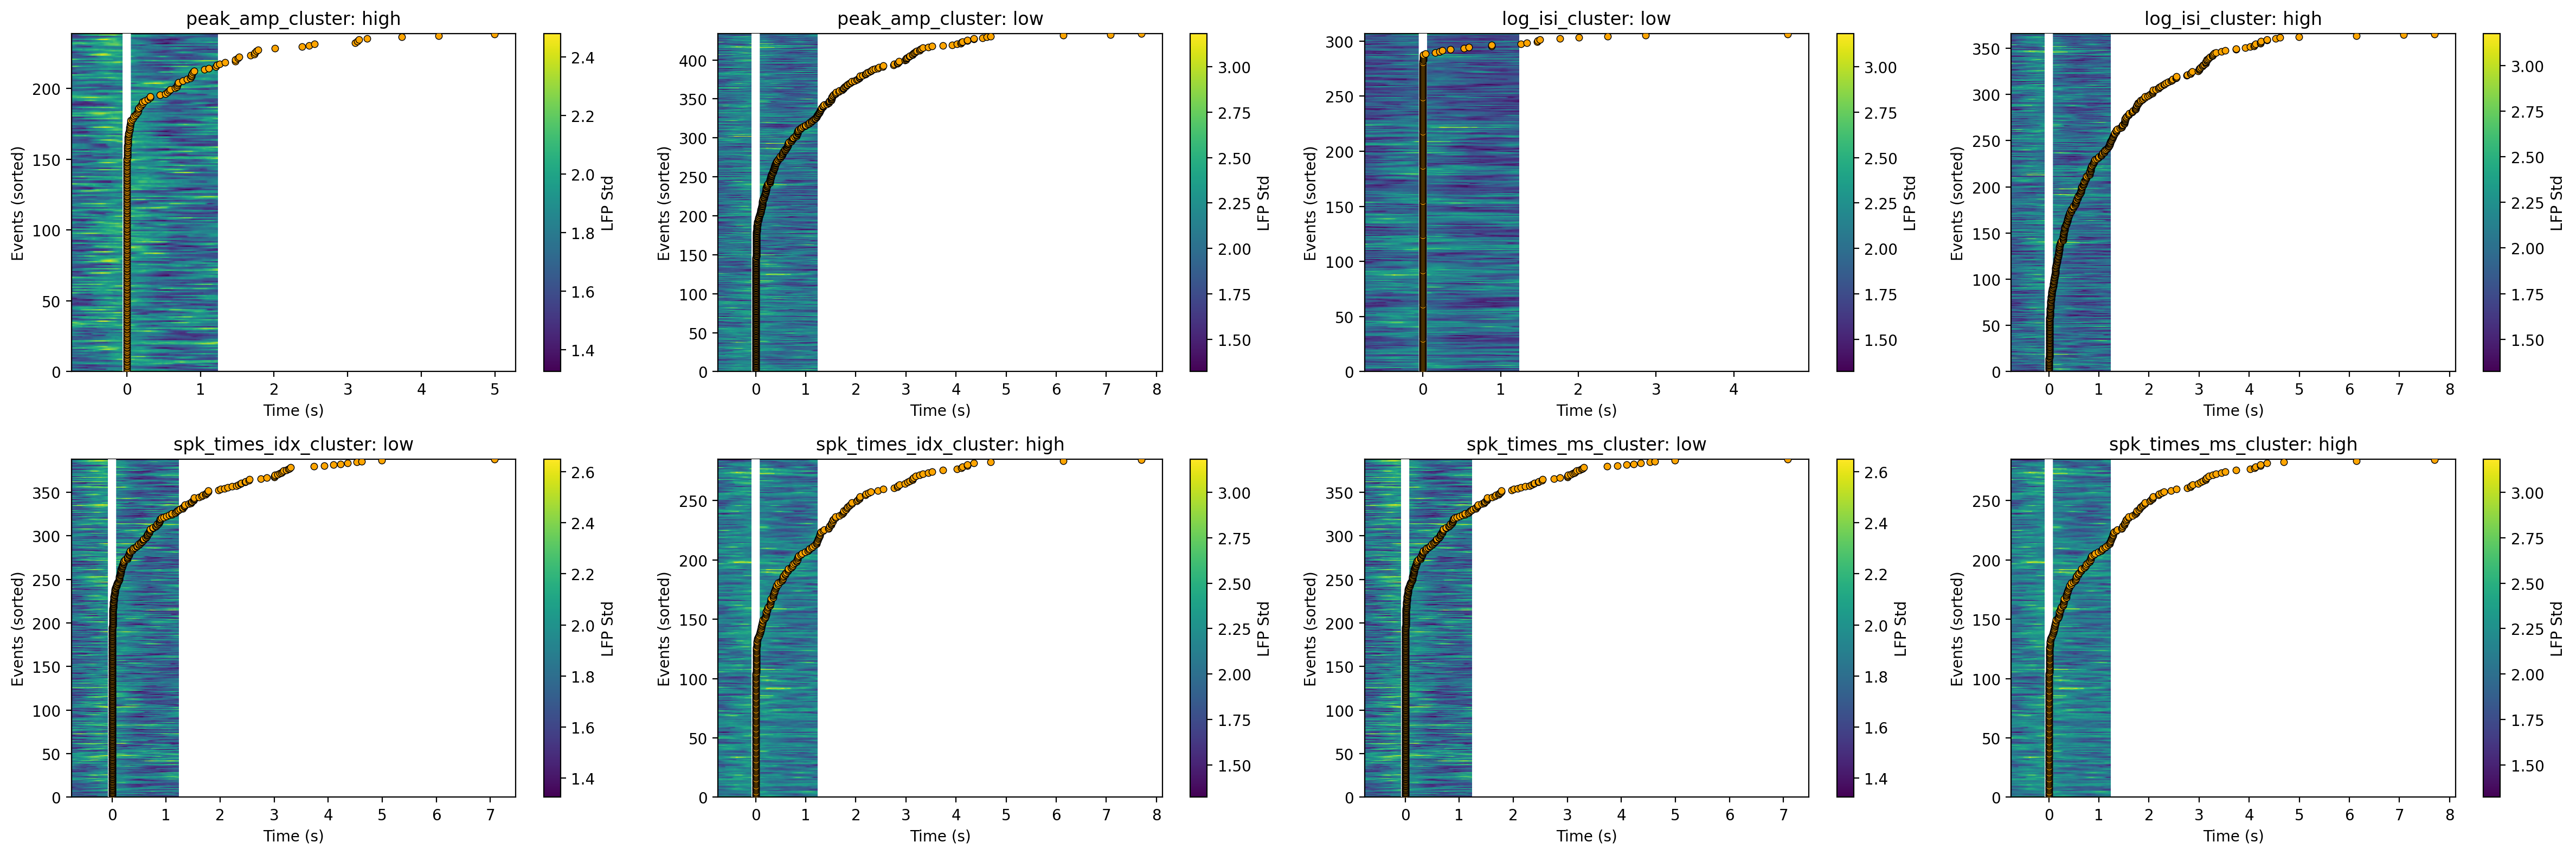

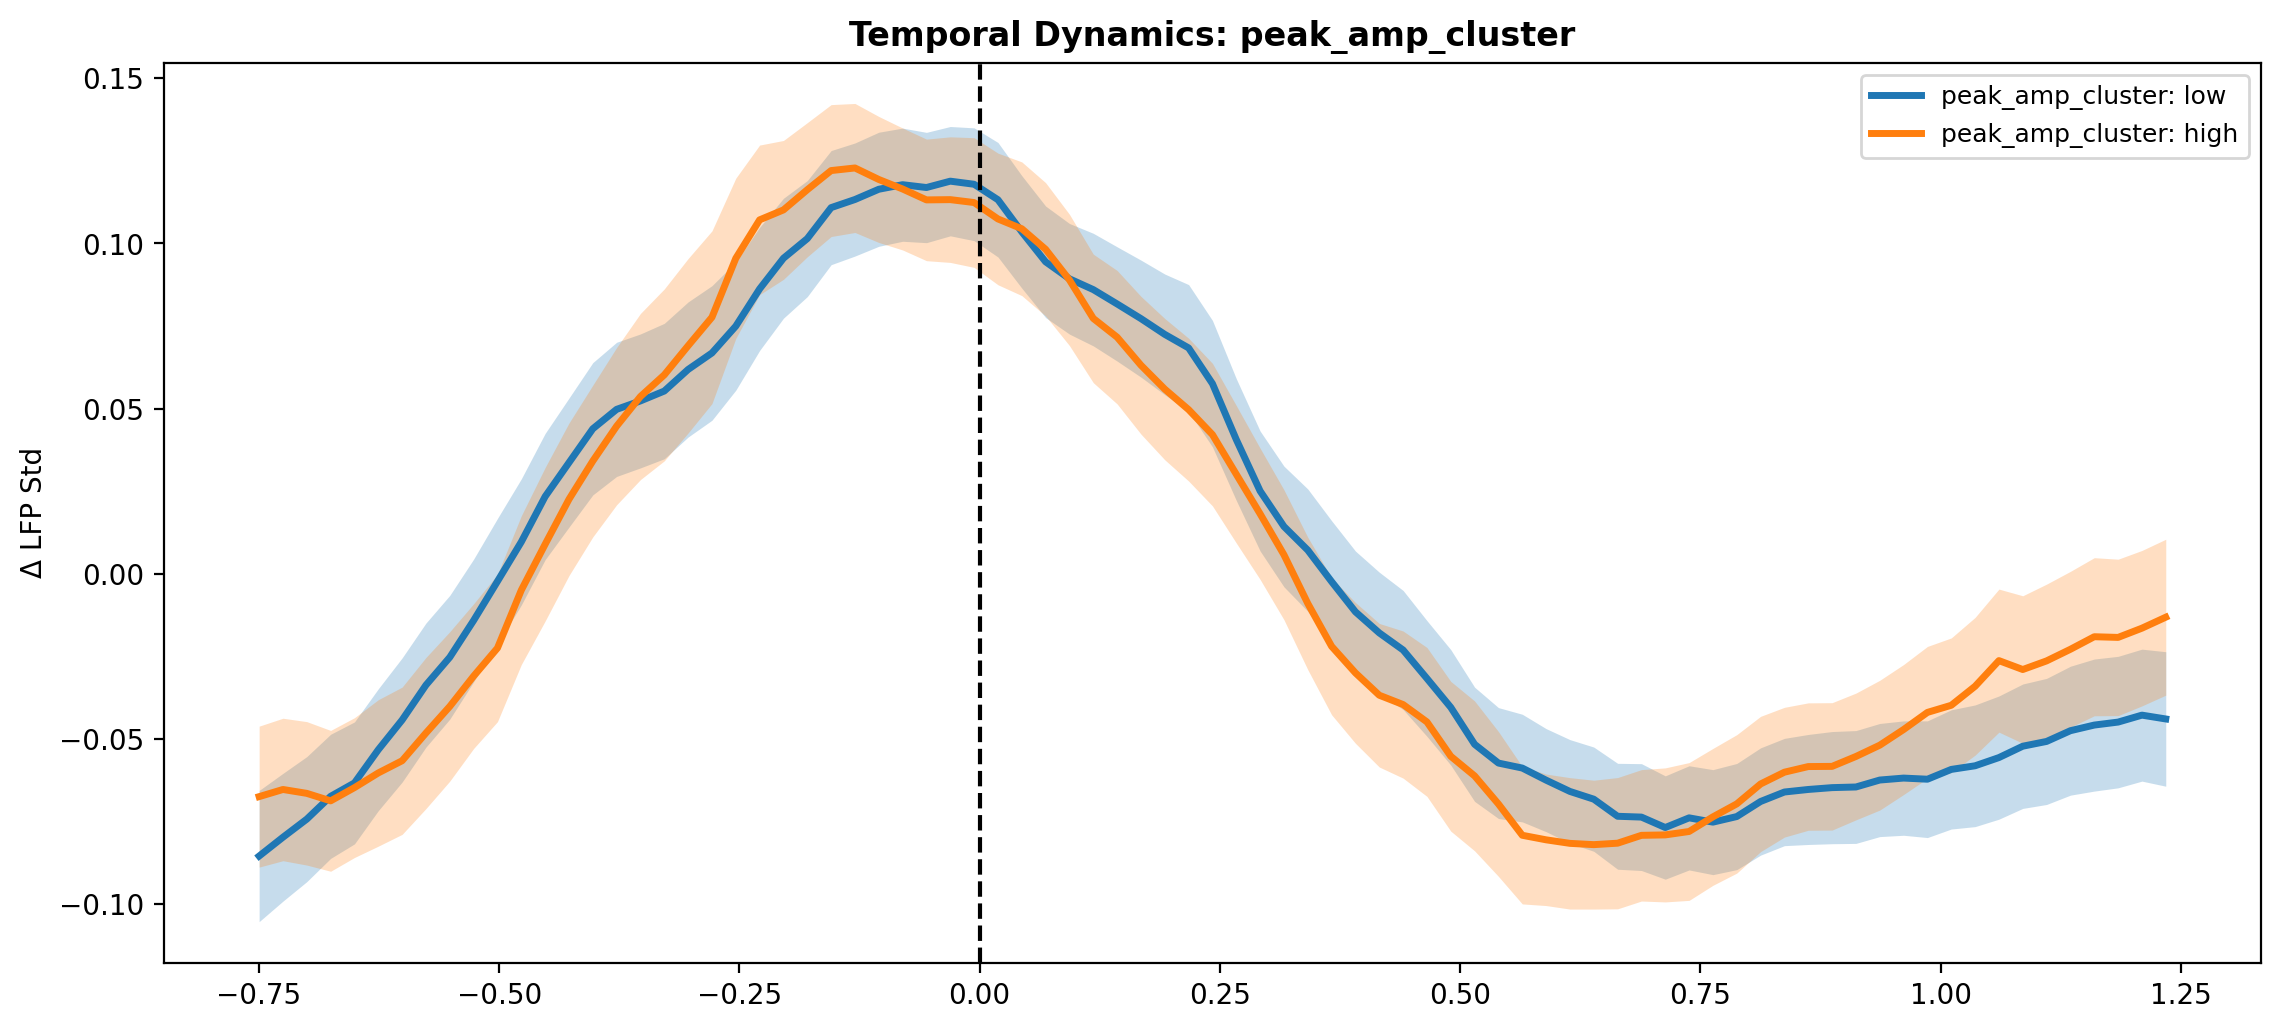

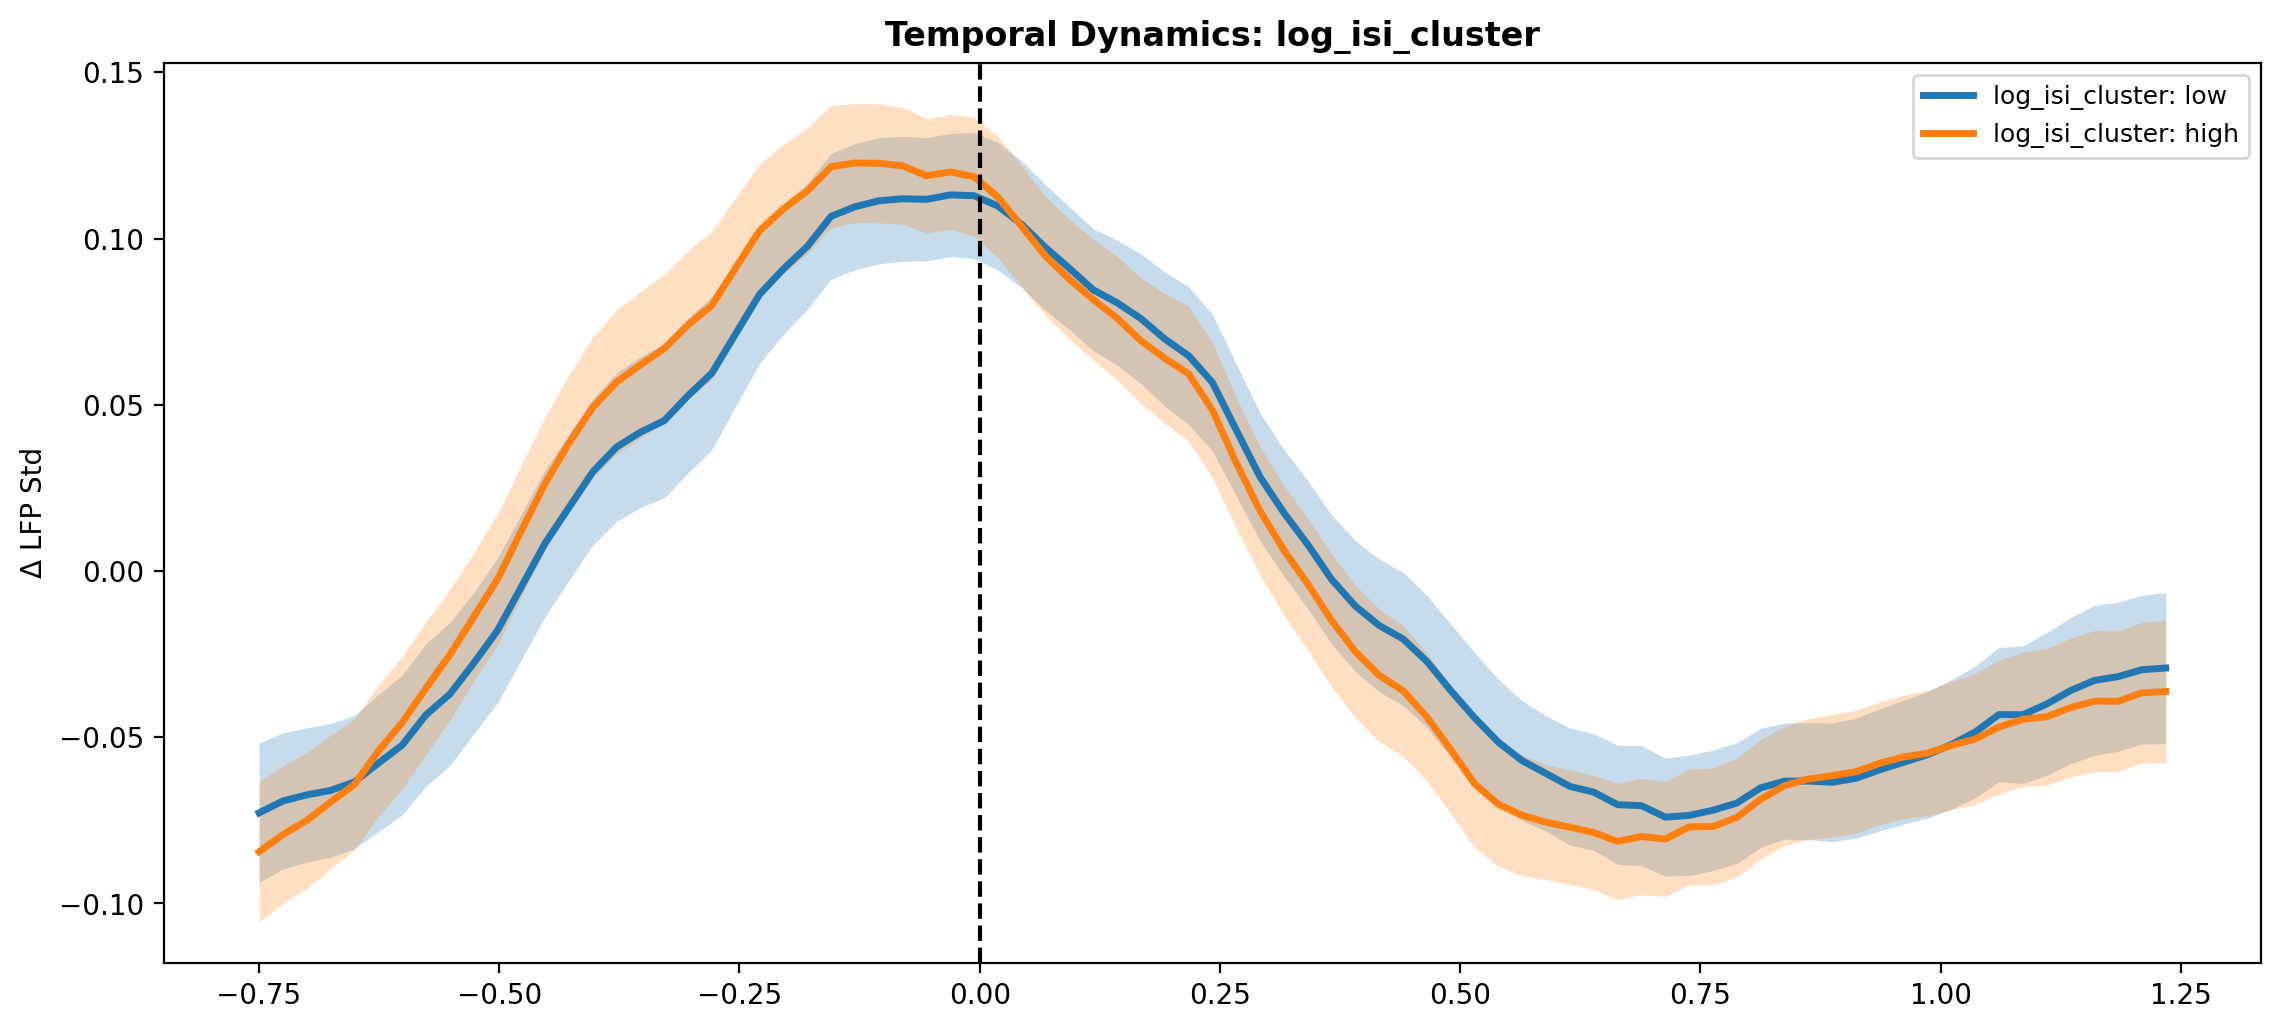

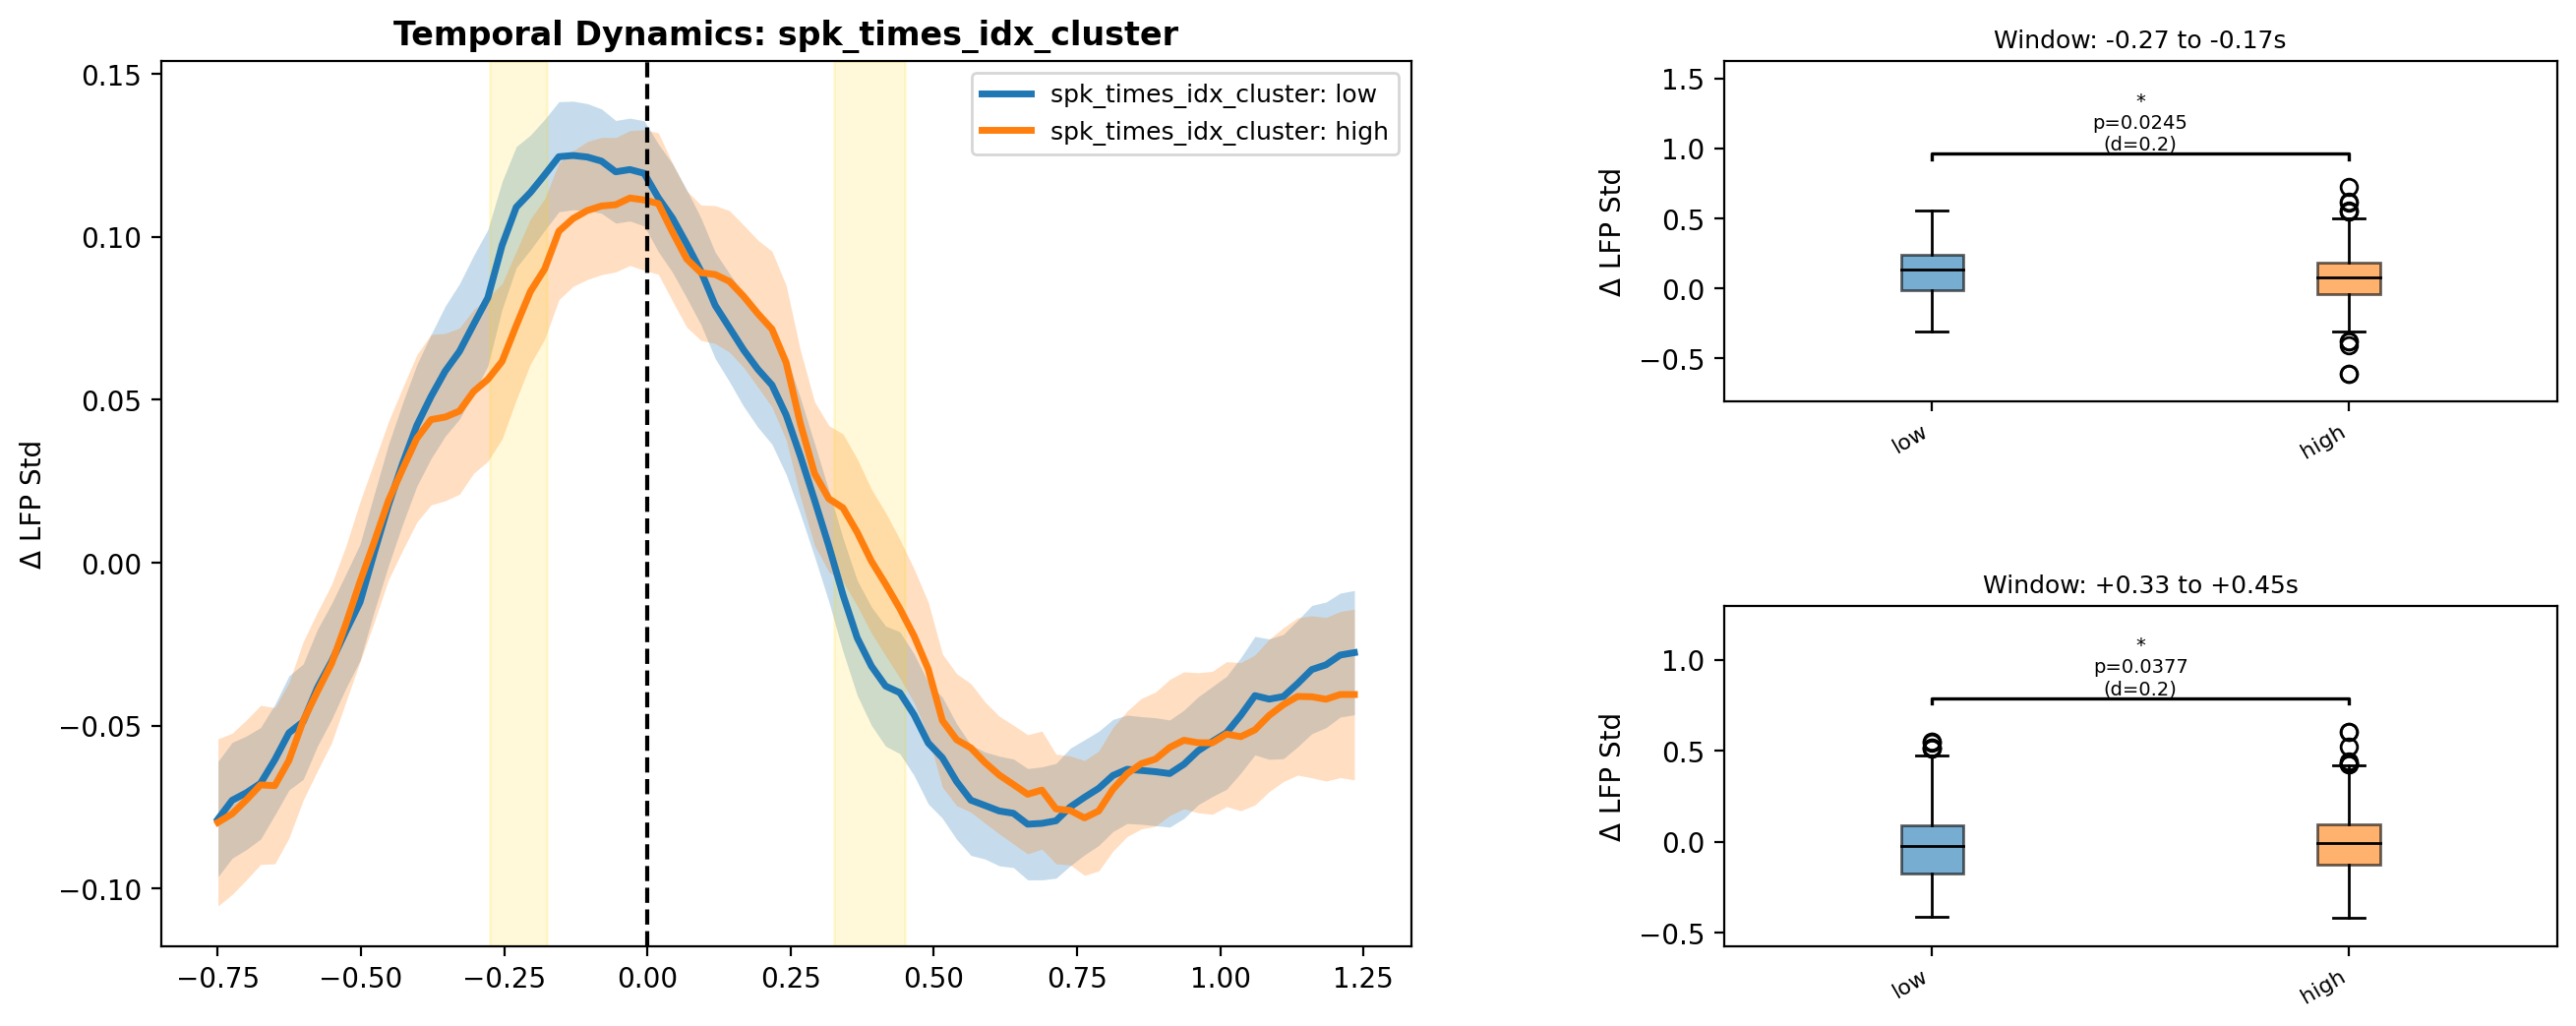

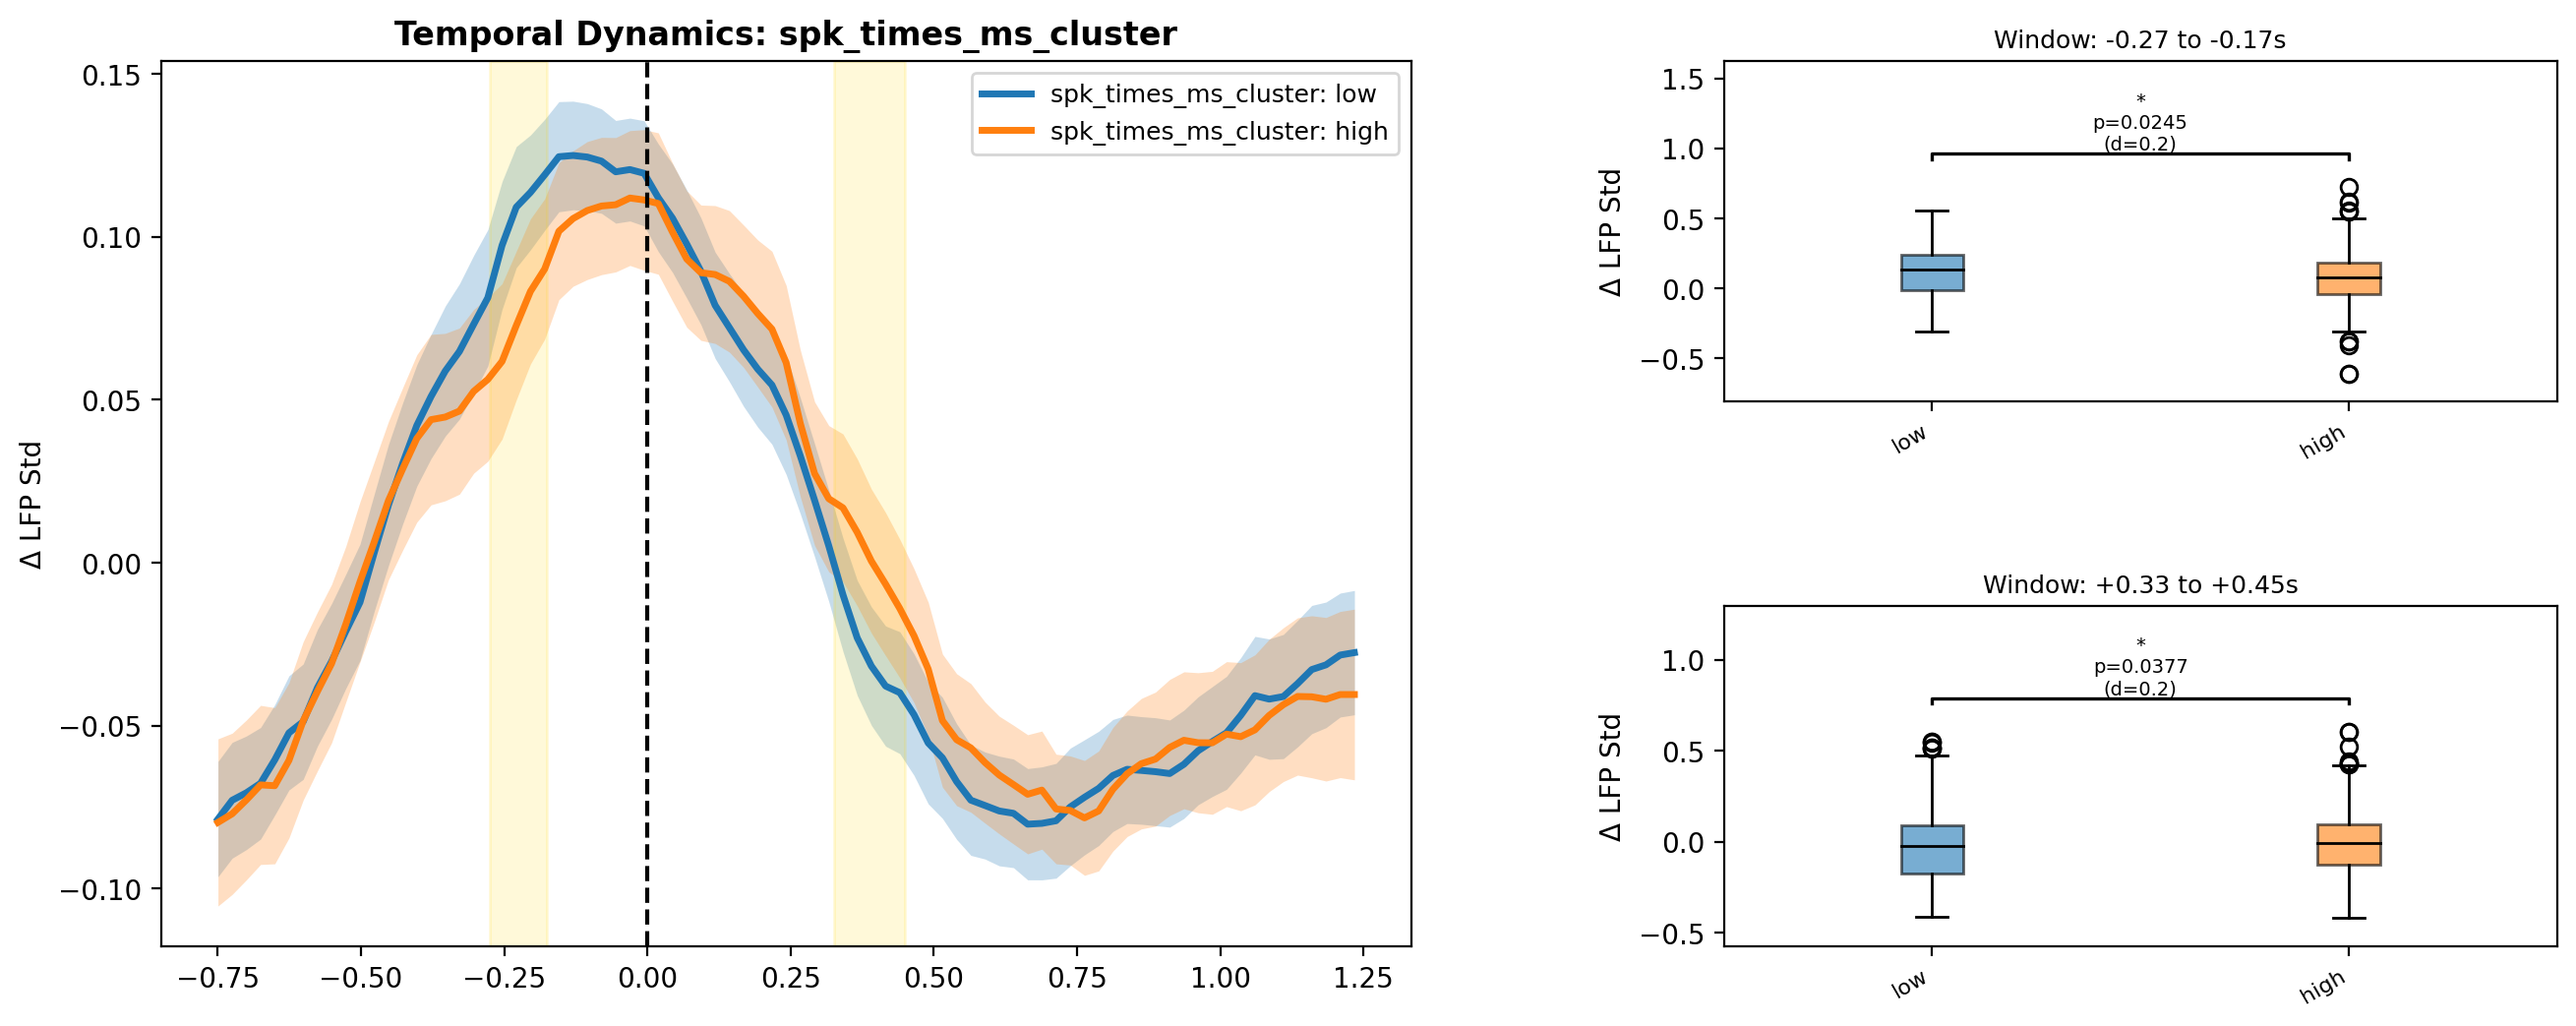


  RUNNING PIPELINE FOR: LFP SPECTRAL EXPONENT



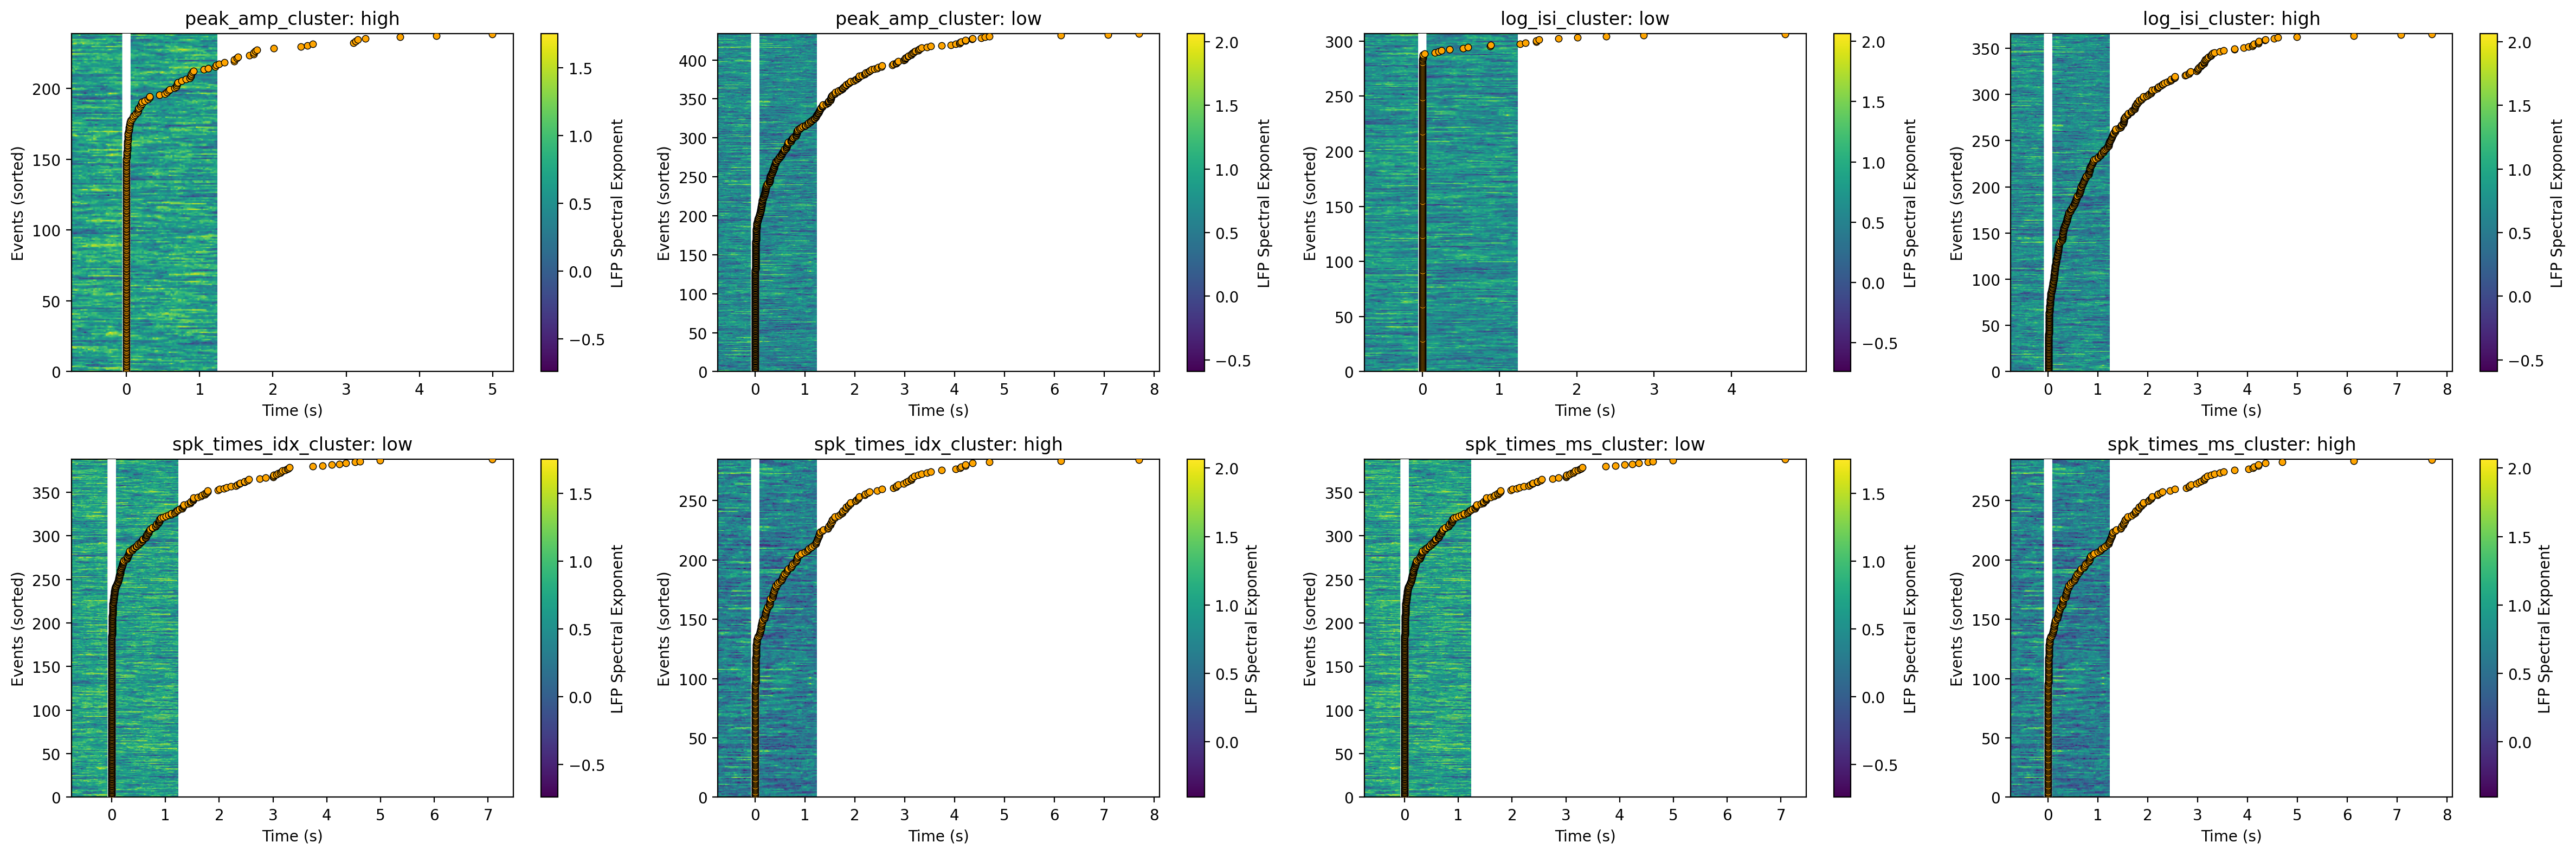

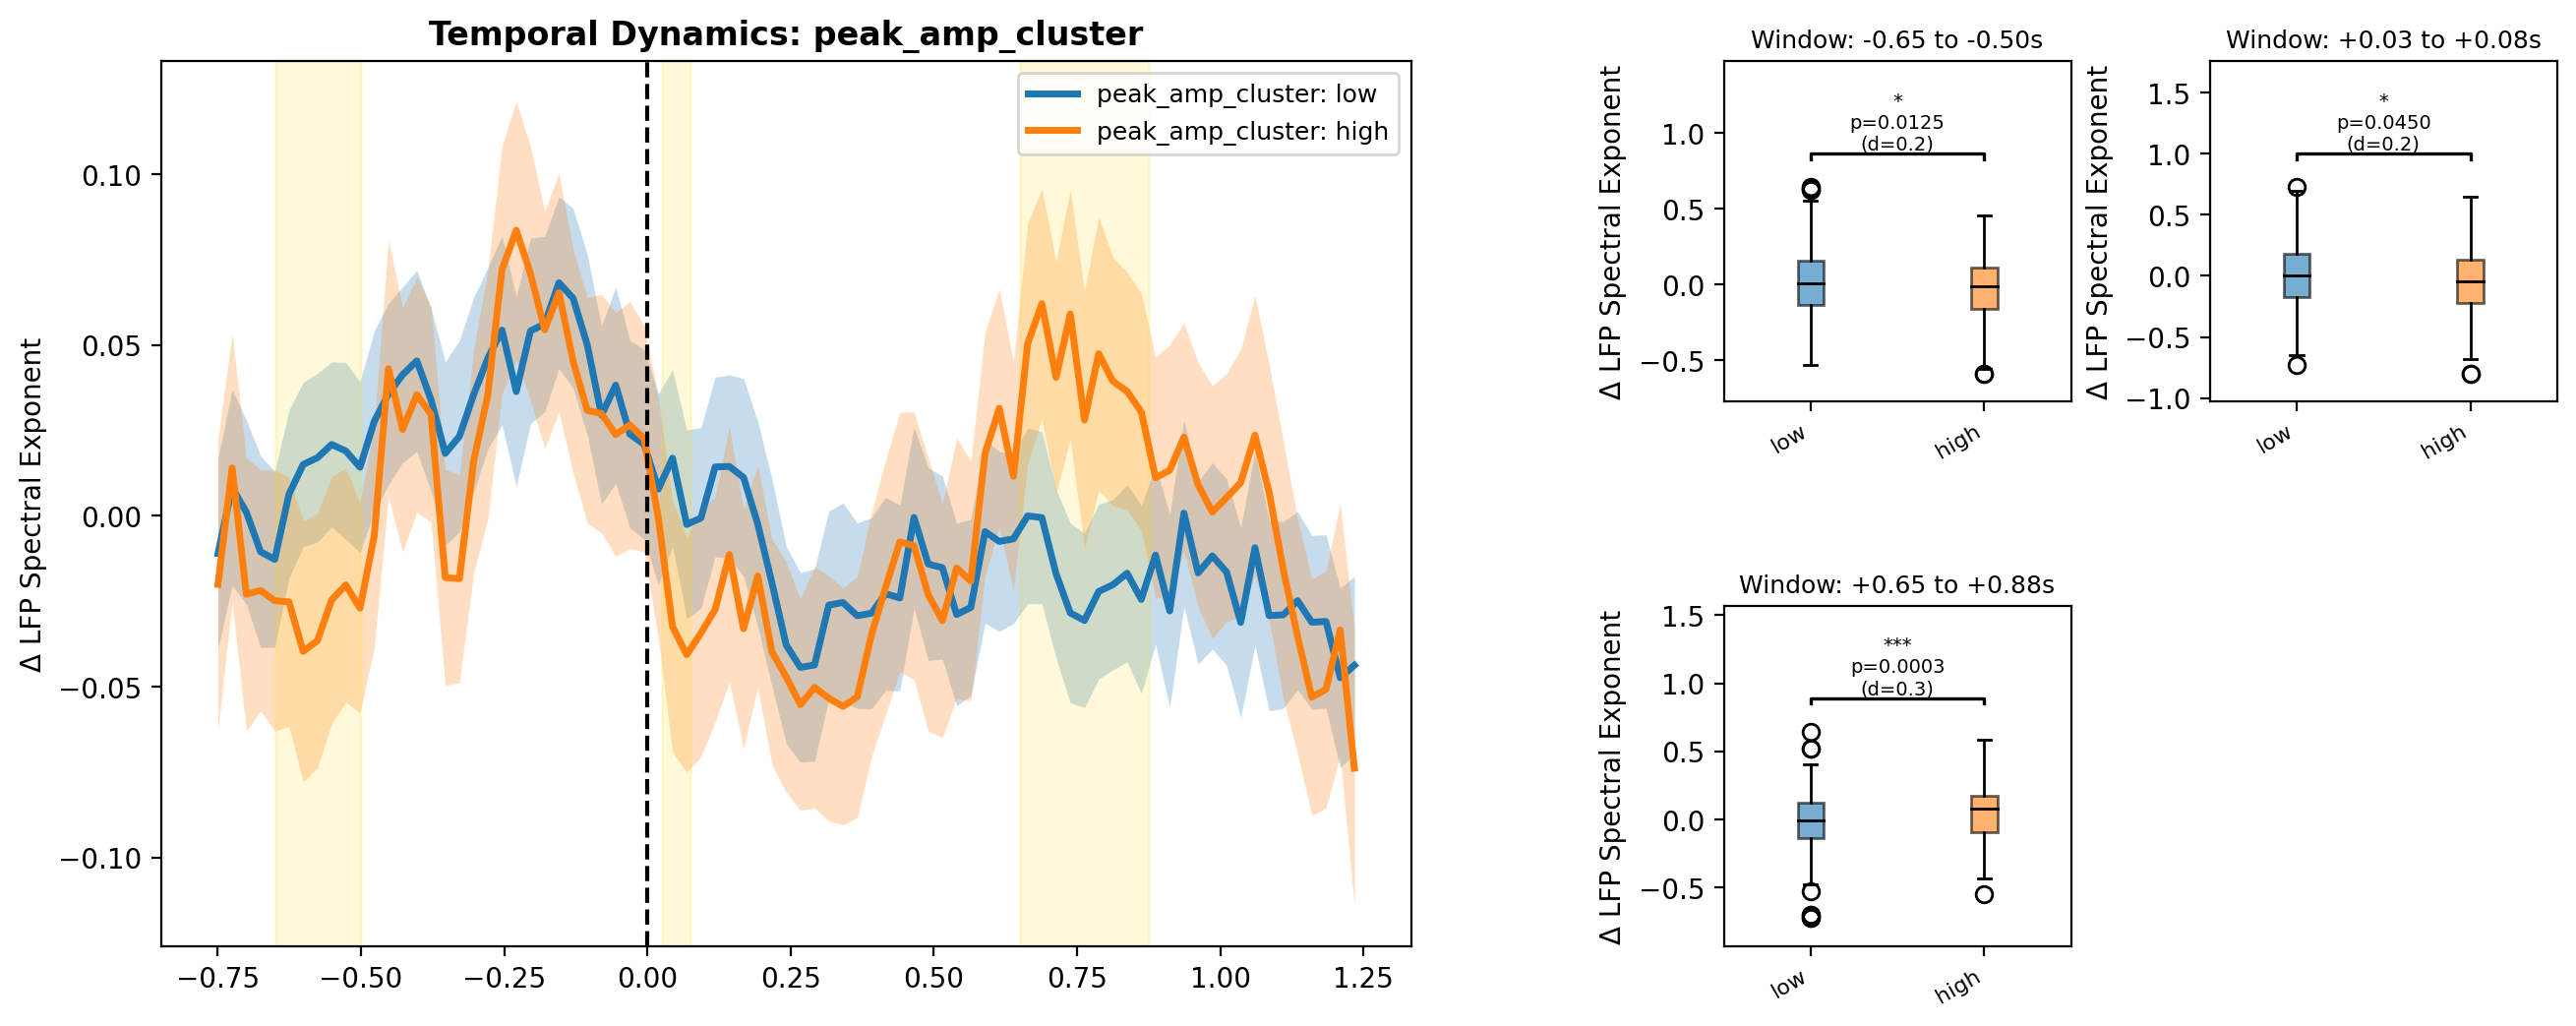

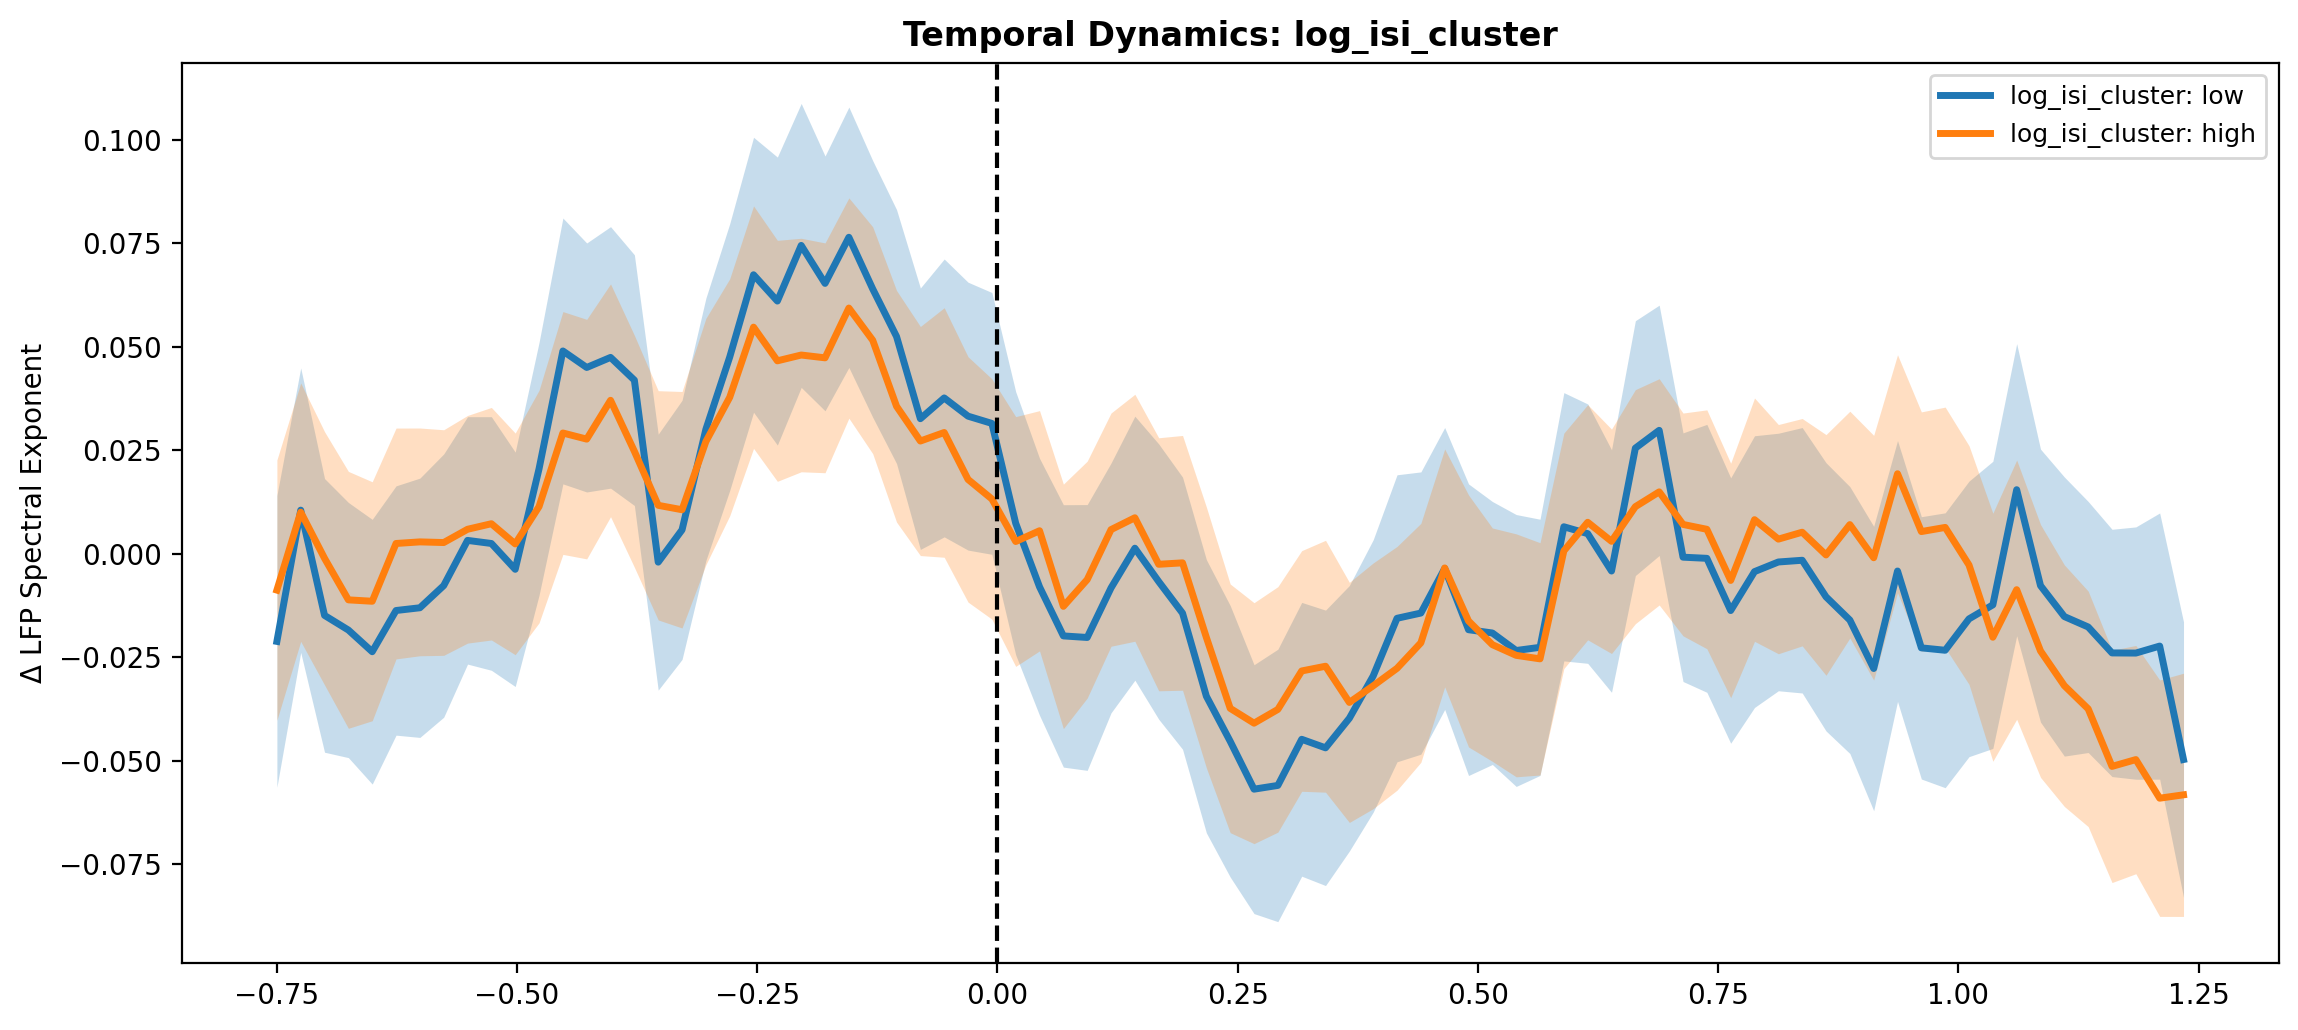

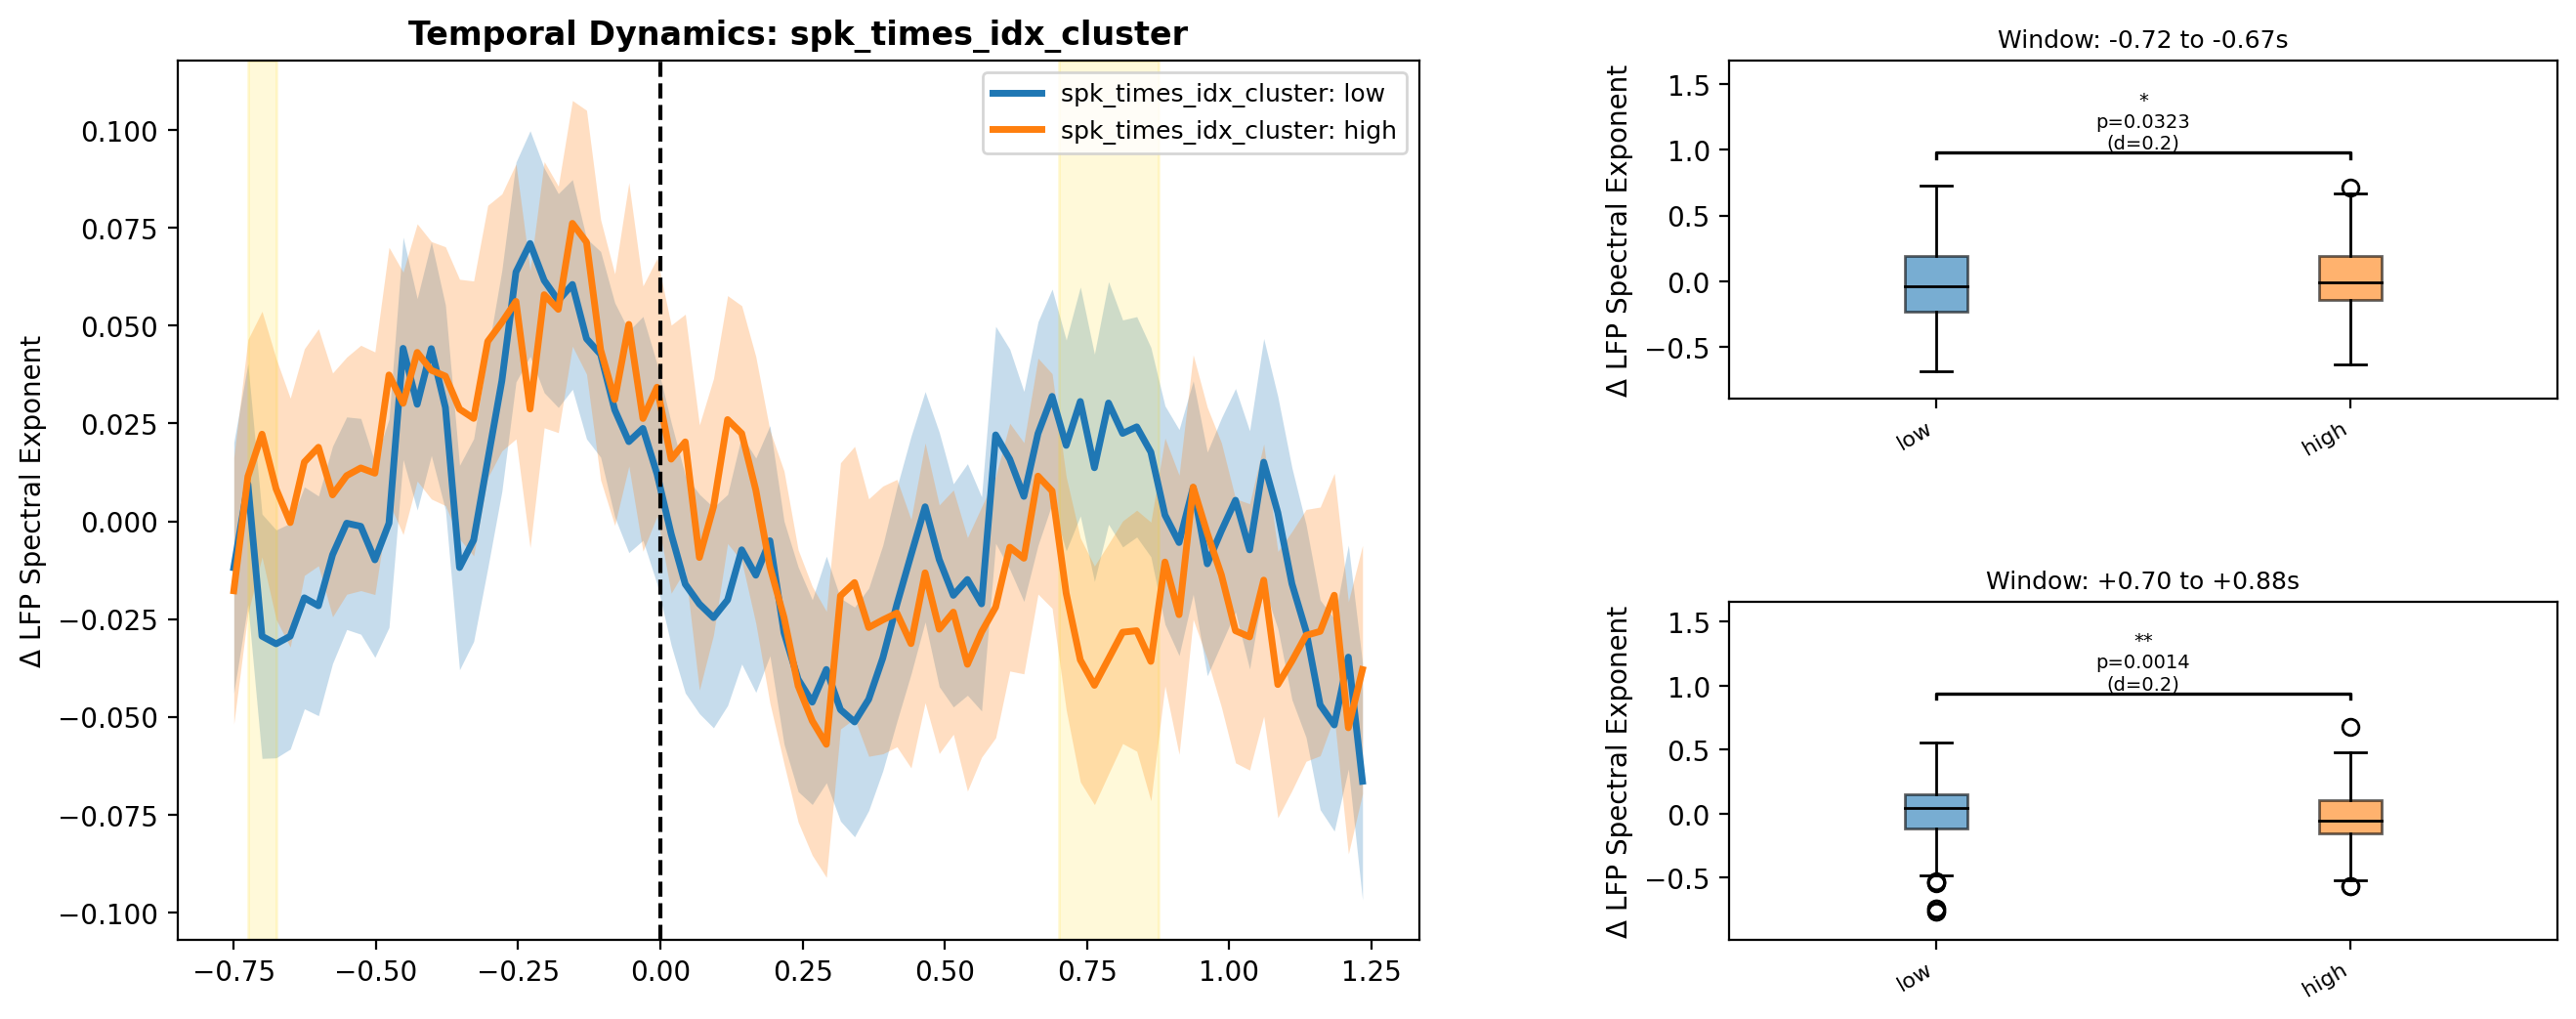

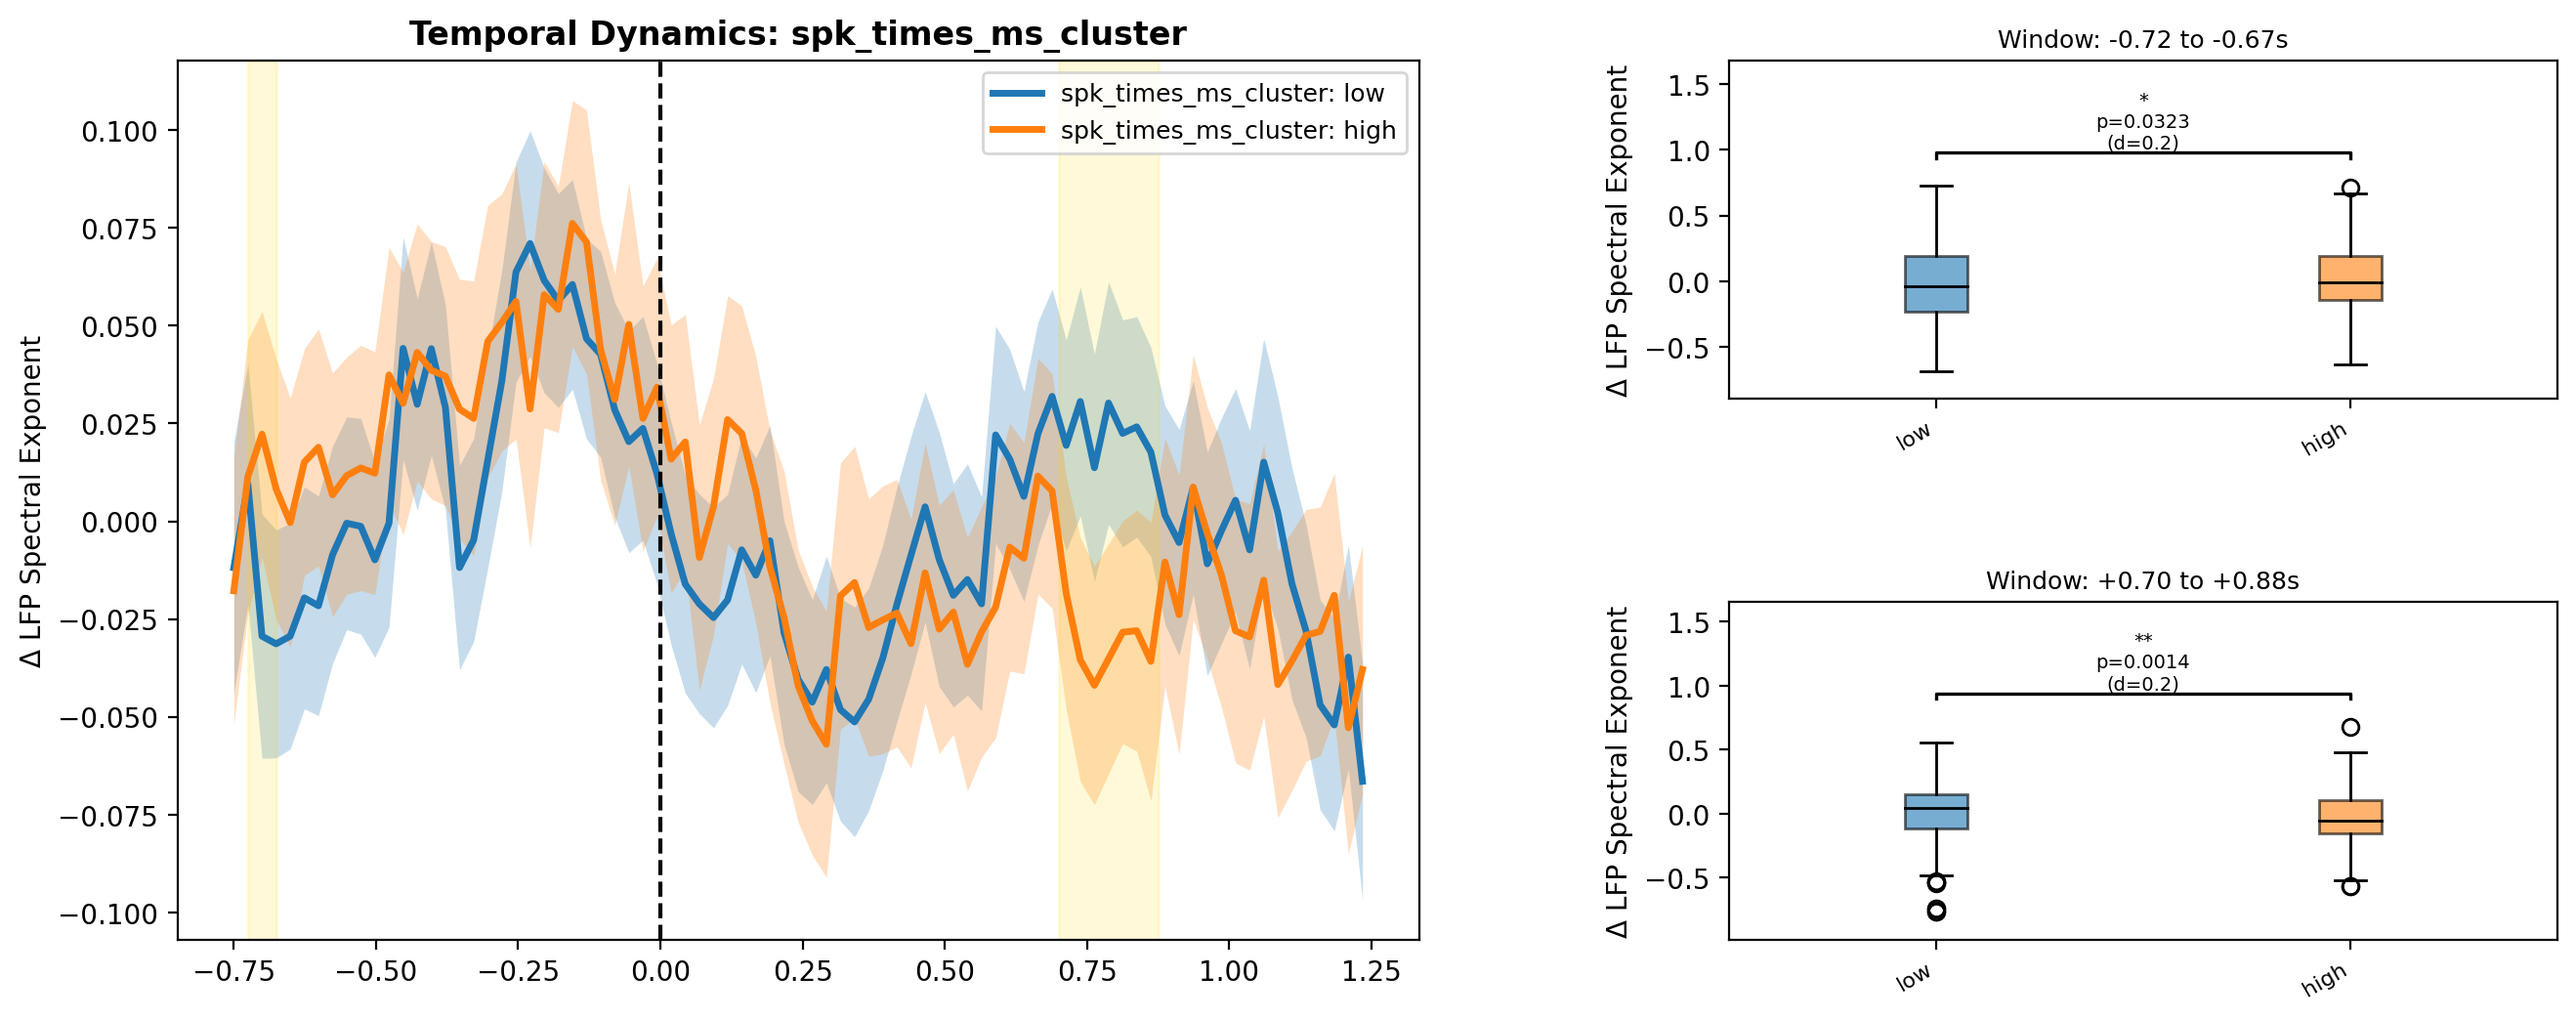


  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/3_sliding_stats.pkl
  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/3_per_spike_data.pkl


In [11]:
features_list = [
    {"feature": "exponent",     "label": "Aperiodic Exponent"},
    {"feature": "offset",       "label": "Aperiodic Offset"},
    {"feature": "band",  "band": "theta",  "label": "Theta AUC"},
    {"feature": "band",  "band": "beta",   "label": "Beta AUC"},
    {"feature": "band",  "band": "gamma",  "label": "Gamma AUC"},
    {"feature": "r_squared",    "label": "r-squared"},
    {"feature": "lfp_mean",     "label": "LFP Mean Amplitude"},
    {"feature": "lfp_std",      "label": "LFP Std"},
    {"feature": "lfp_exponent", "label": "LFP Spectral Exponent"},
]

master_results = run_master_LFP_spk_analysis(
    cell_id=str(cell_num),
    specparam_by_spike=specparam_by_spike,
    groups=groups,
    features_to_analyze=features_list,
    lfp_windows_by_spike=lfp_windows_by_spike,
    window_width=0.05,
    step_size=0.025,
    p_threshold=0.05,
    force_recompute=FORCE_STATS,
    plot=True,
)


## Plot significant windows

In [12]:
plot_significant_windows_spectra(df_features_clust, specparam_by_spike, master_results)



Extacting peak_amp_cluster at significant window: -0.750s to 0.125s
  -> Failed to extract valid spectra at t=-0.3122445345505622s

Extacting peak_amp_cluster at significant window: 0.400s to 1.225s
  -> Failed to extract valid spectra at t=0.8127554654494387s

Extacting peak_amp_cluster at significant window: -0.650s to -0.500s
  -> Failed to extract valid spectra at t=-0.5747445345505624s

Extacting peak_amp_cluster at significant window: 0.025s to 0.075s
  -> Failed to extract valid spectra at t=0.05025546544943813s

Extacting peak_amp_cluster at significant window: 0.650s to 0.875s
  -> Failed to extract valid spectra at t=0.7627554654494388s

Extacting log_isi_cluster at significant window: -0.750s to -0.300s
  -> Failed to extract valid spectra at t=-0.5248544313301645s

Extacting spk_times_idx_cluster at significant window: -0.750s to -0.075s
  -> Failed to extract valid spectra at t=-0.4123544313301644s

Extacting spk_times_idx_cluster at significant window: 0.125s to 1.225s
 